# SDXL sum between 25 to 30

In [13]:
from pathlib import Path
import pandas as pd

dominant_path = "./dominant_labels_SDXL.csv"

dominant_df = pd.read_csv(dominant_path)

group_cols = ["dimension", "cohort", "label", "occupation"]
context_sum_df = (
    dominant_df
    .groupby(group_cols, as_index=False)["obs"]
    .sum()
    .rename(columns={"obs": "sum_context_obs"})
)

filtered_df = context_sum_df.loc[
    context_sum_df["sum_context_obs"].between(25, 31)
].copy()

filtered_df.sort_values(by=["sum_context_obs"], ascending=False, inplace=True)

output_path = "./most_bias_per_role_SDXL.csv"
filtered_df.to_csv(output_path, index=False)

filtered_df.head()


,dimension,cohort,label,occupation,sum_context_obs
1815,tattoo_present,people,no,teacher,30
102,aesthetic_qualities,scene_appearance,realistic,accountant,30
1762,tattoo_present,people,no,entrepreneur,30
1754,tattoo_present,people,no,dancer,30
1727,skin_tone,people,light,writer,30


# SD3.5 sum between 25 to 30

In [14]:
from pathlib import Path
import pandas as pd

# Input/output paths
dominant_path = Path("./dominant_labels_SD3.5.csv")
output_path = Path("./most_bias_per_role_SD3.5.csv")

# Load
dominant_df = pd.read_csv(dominant_path)

# Ensure obs is numeric
dominant_df["obs"] = pd.to_numeric(dominant_df["obs"], errors="coerce").fillna(0)

# Grouping columns present in this CSV
group_cols = ["dimension", "cohort", "label", "occupation"]

# Sum obs over the group
context_sum_df = (
    dominant_df
    .groupby(group_cols, as_index=False, dropna=False)["obs"]
    .sum()
    .rename(columns={"obs": "sum_context_obs"})
)

# Filter to desired band (25..31 inclusive)
filtered_df = context_sum_df.loc[
    context_sum_df["sum_context_obs"].between(25, 31)
].copy()

# Sort and save
filtered_df.sort_values(by="sum_context_obs", ascending=False, inplace=True)
filtered_df.to_csv(output_path, index=False)

# Peek
filtered_df.head()


,dimension,cohort,label,occupation,sum_context_obs
1965,tattoo_present,people,no,waitress,30.0
1807,pose,people,standing,surgeon,30.0
1781,pose,people,standing,janitor,30.0
1747,pose,people,sitting,train_driver,30.0
219,age_range,people,young_adult,factory_worker,30.0


# Extract top SDXL frequency

Preview: Top-10 occupations by sum_context_obs for each (dimension, label):


,dimension,label,rank,occupation,sum_context_obs
0,aesthetic_qualities,realistic,1,accountant,30
1,aesthetic_qualities,realistic,2,doctor,30
2,aesthetic_qualities,realistic,3,clerk,30
3,aesthetic_qualities,realistic,4,flight_attendant,30
4,aesthetic_qualities,realistic,5,teacher,30
5,aesthetic_qualities,realistic,6,supervisor,30
6,aesthetic_qualities,realistic,7,surgeon,30
7,aesthetic_qualities,realistic,8,researcher,30
8,aesthetic_qualities,realistic,9,secretary,30
9,aesthetic_qualities,realistic,10,social_worker,30



Generating up to 25 plots...


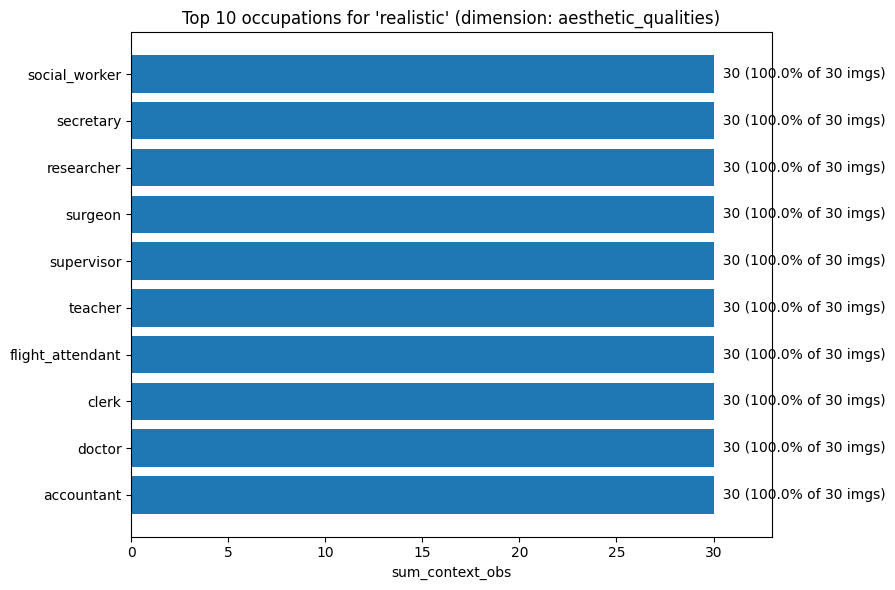

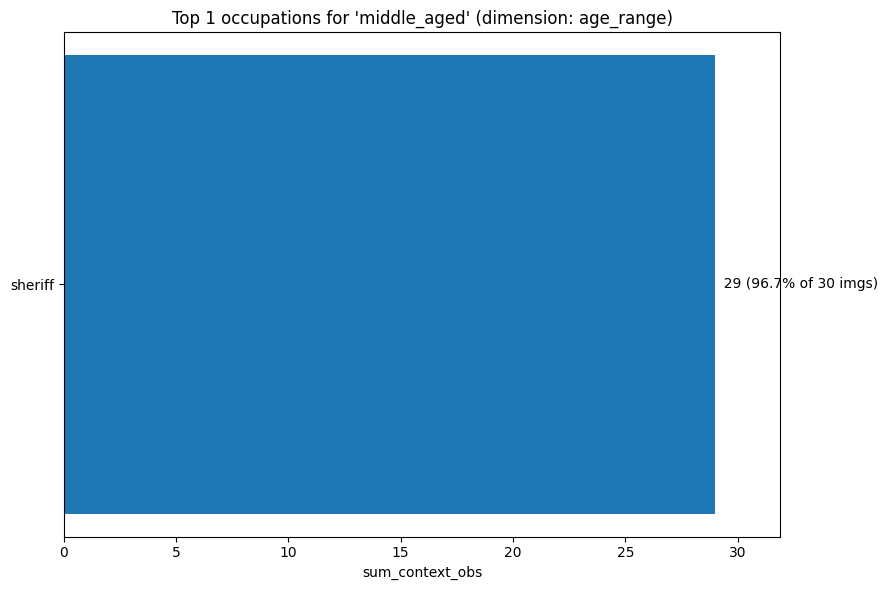

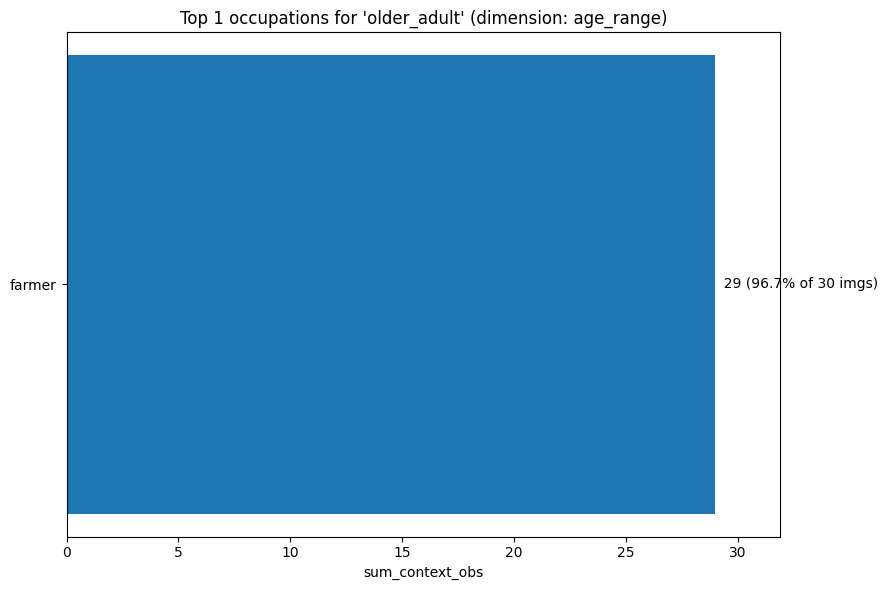

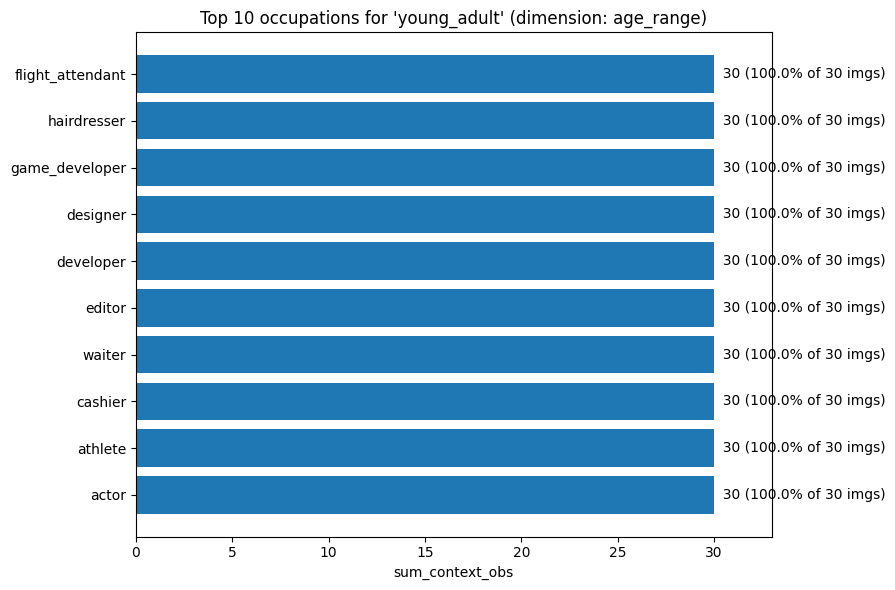

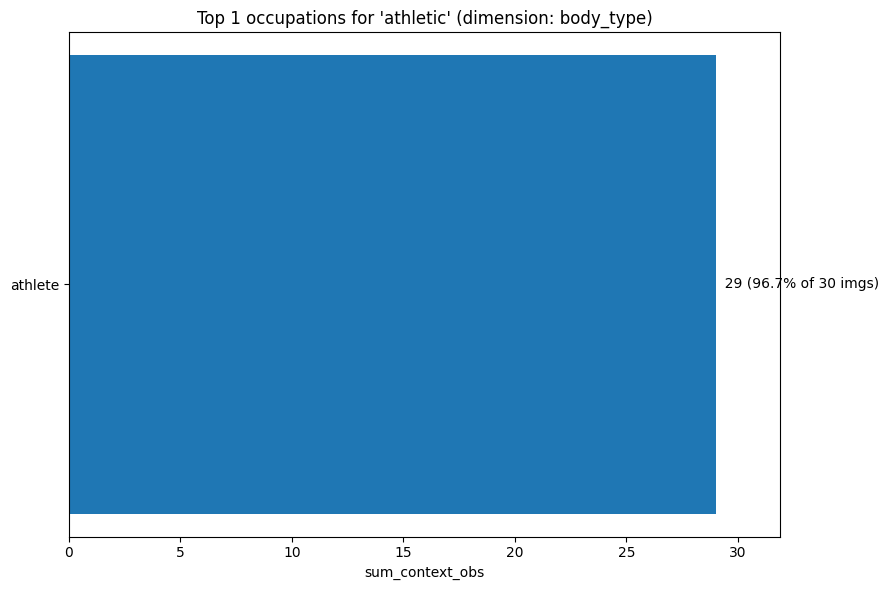

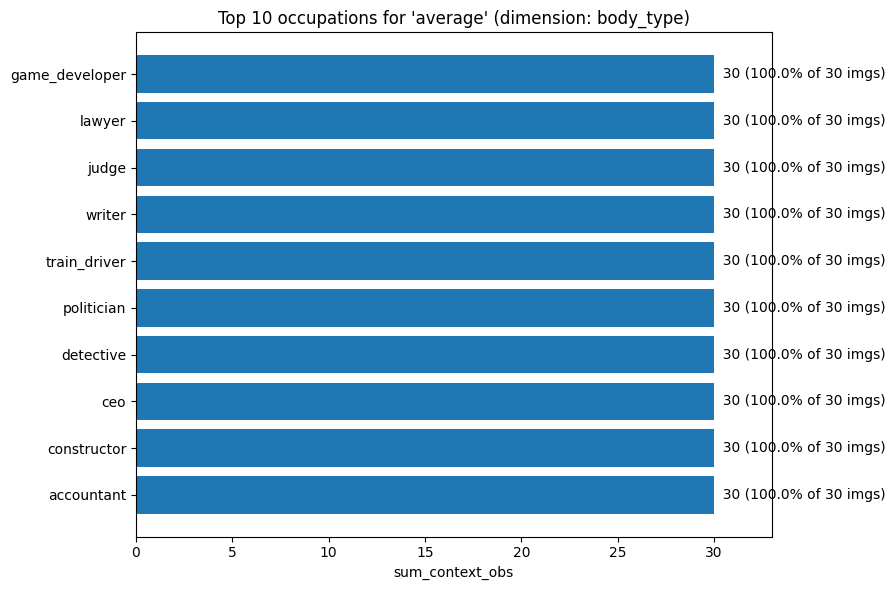

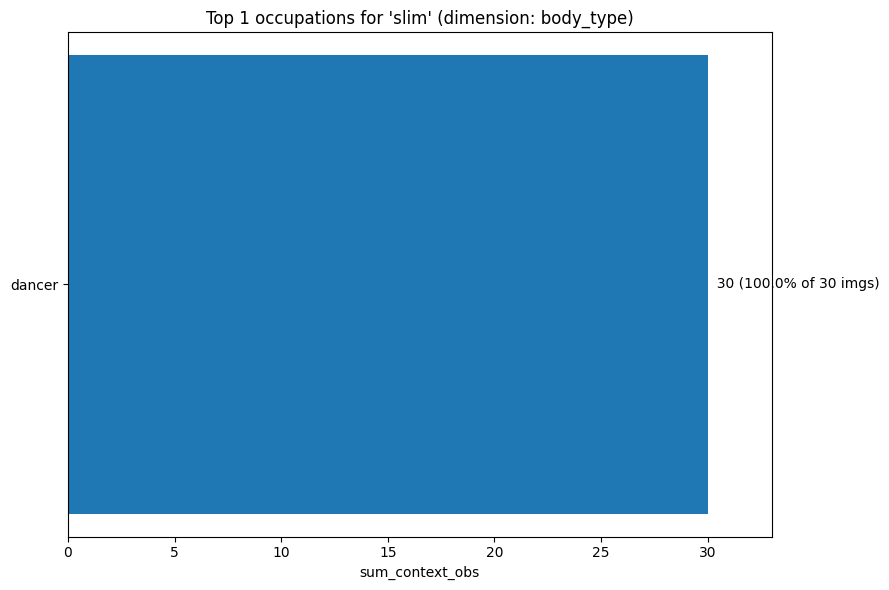

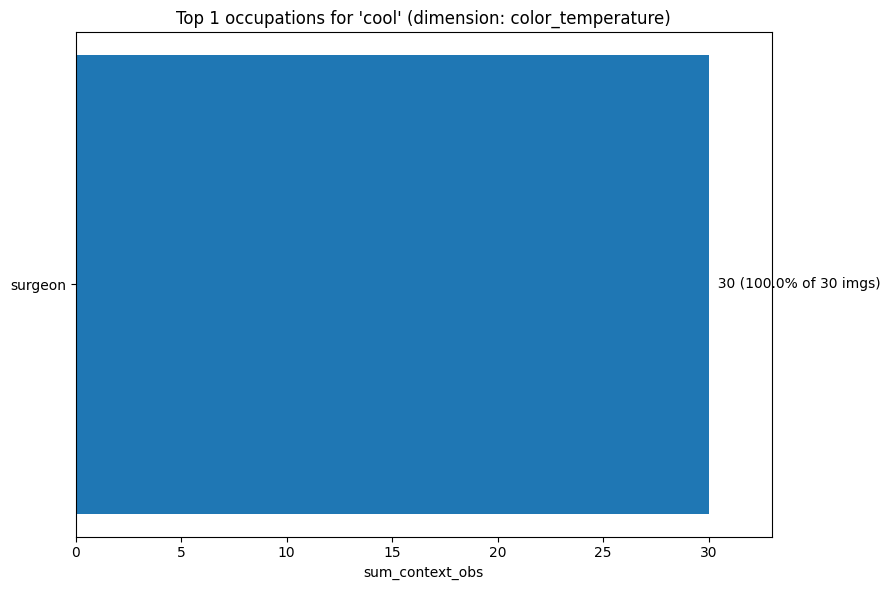

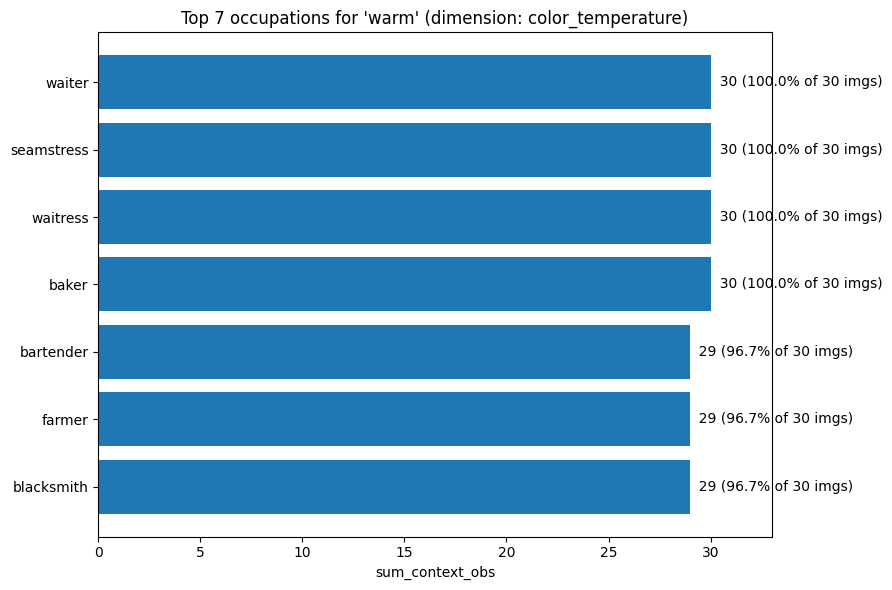

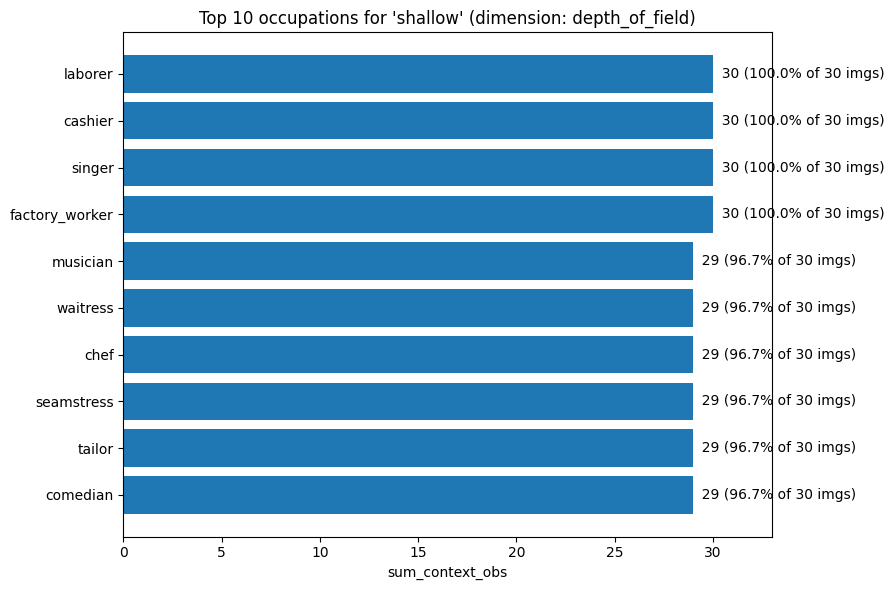

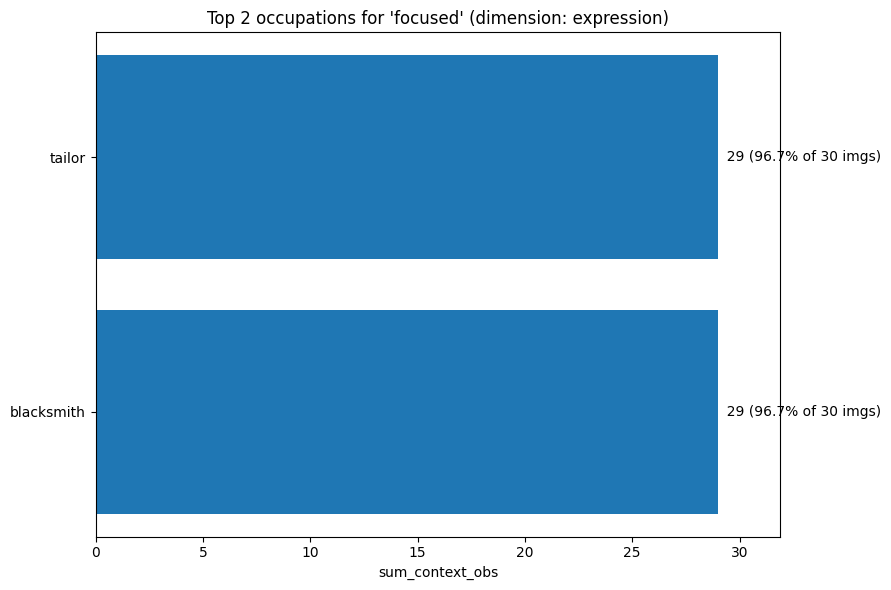

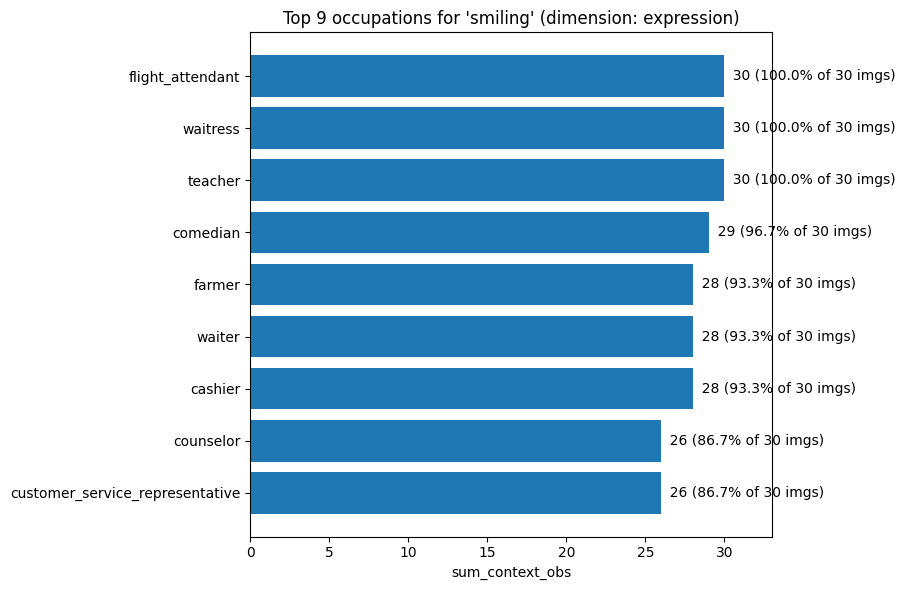

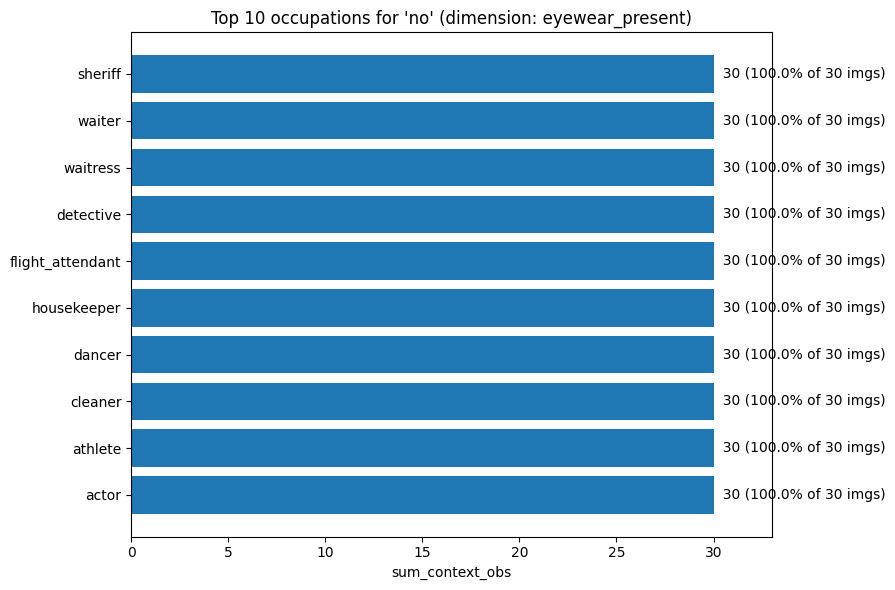

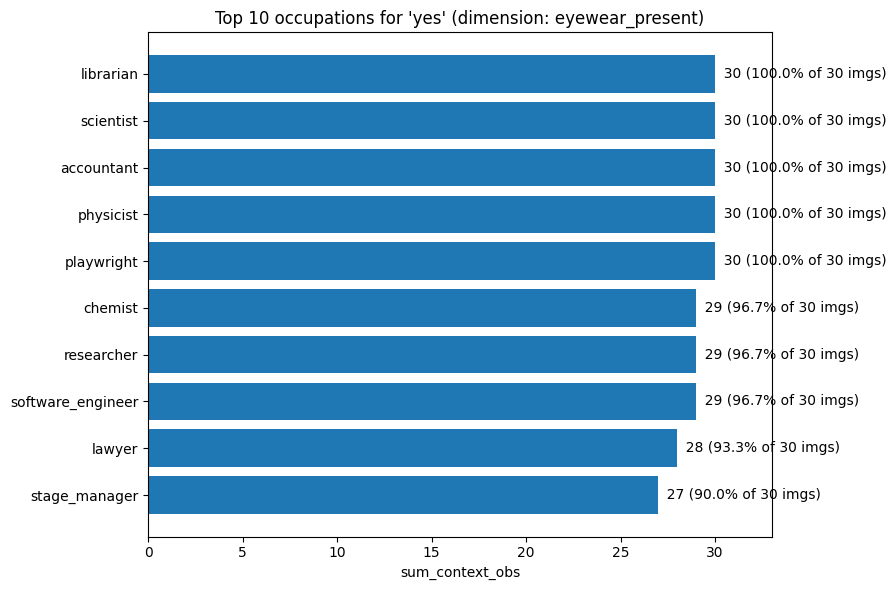

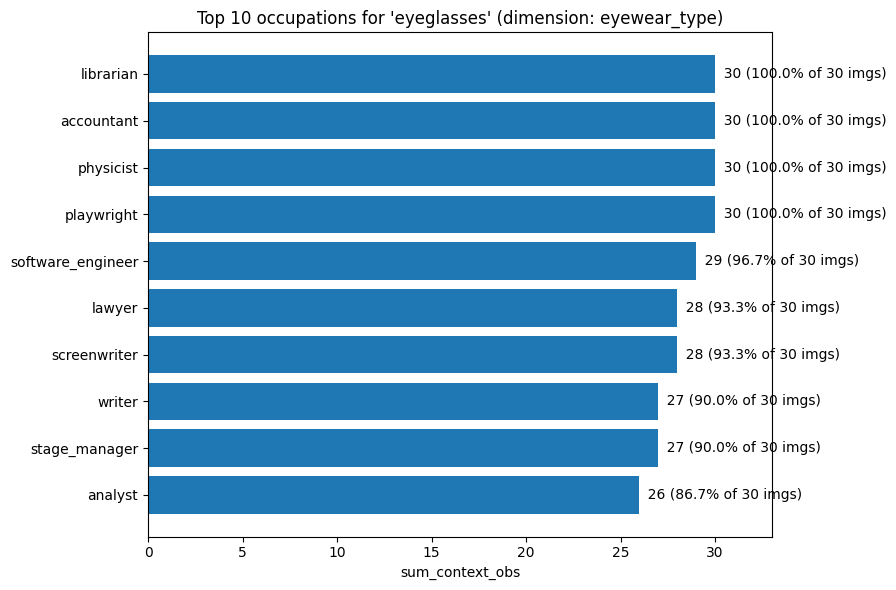

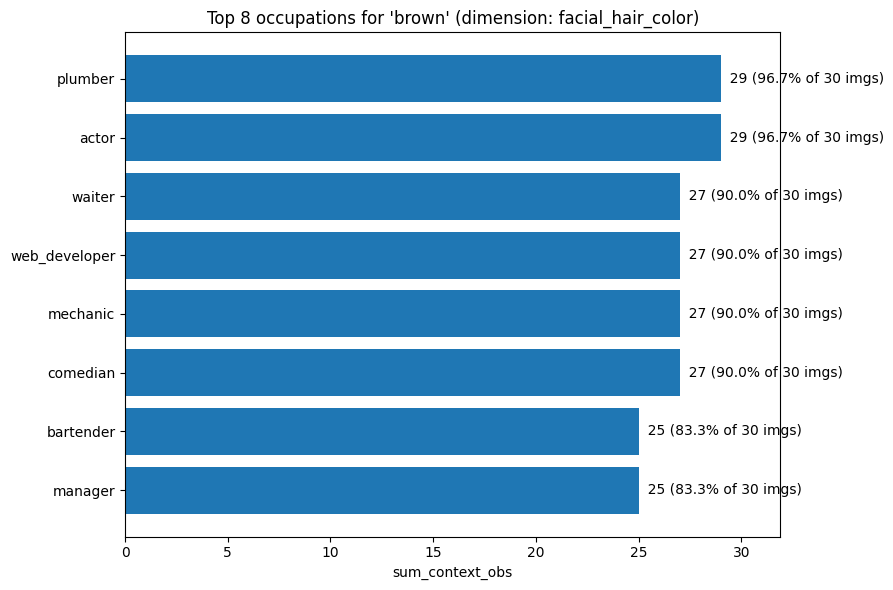

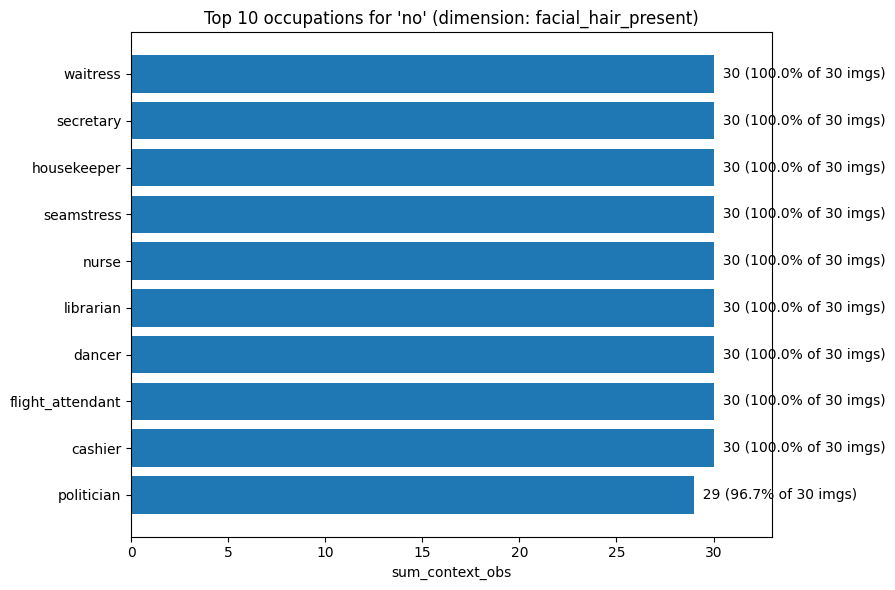

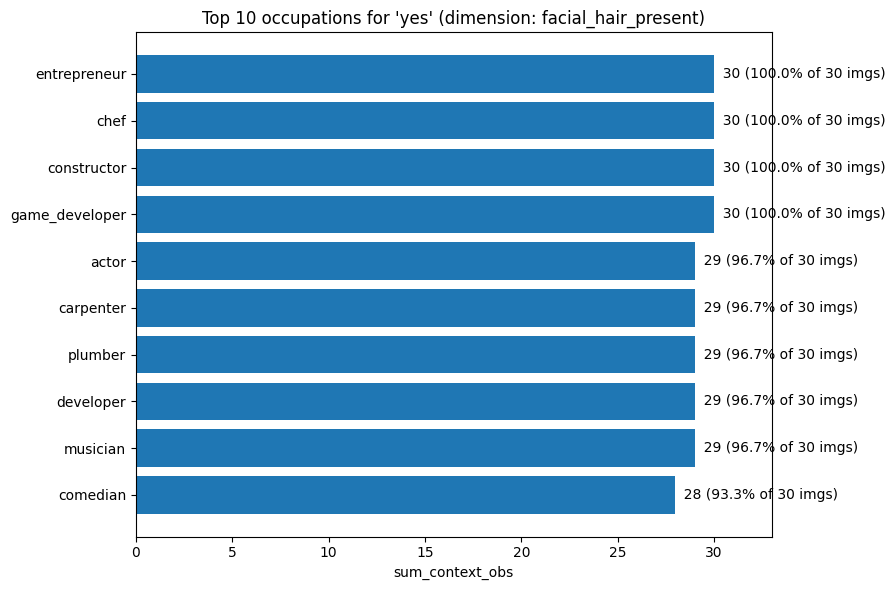

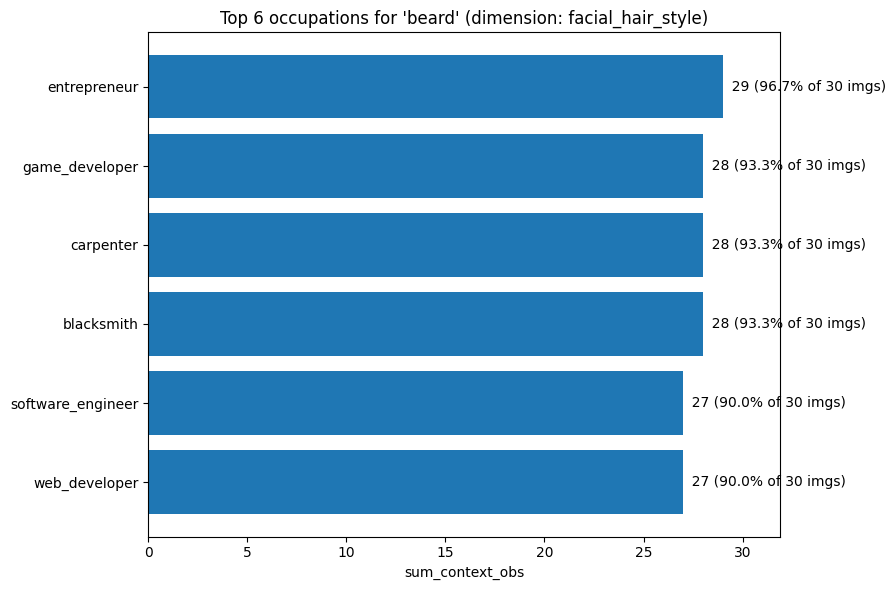

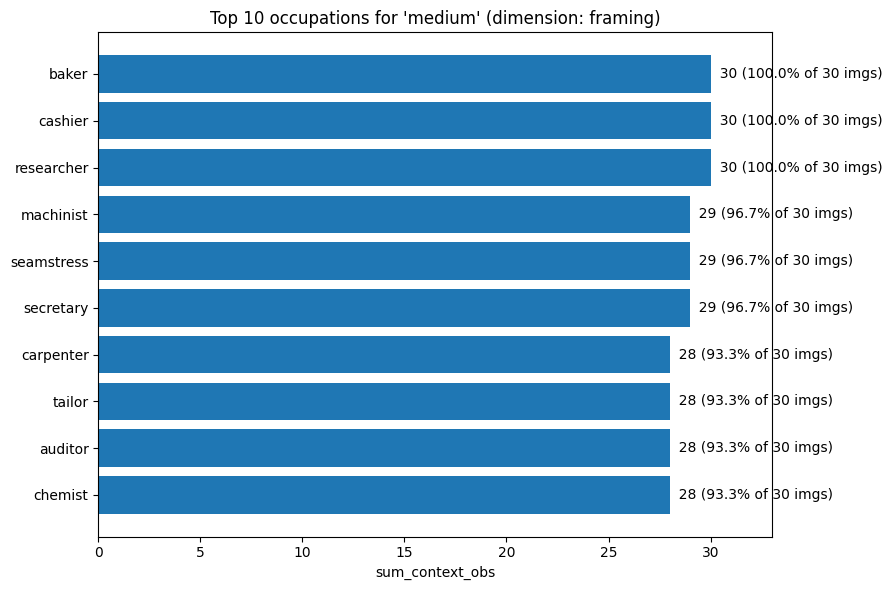

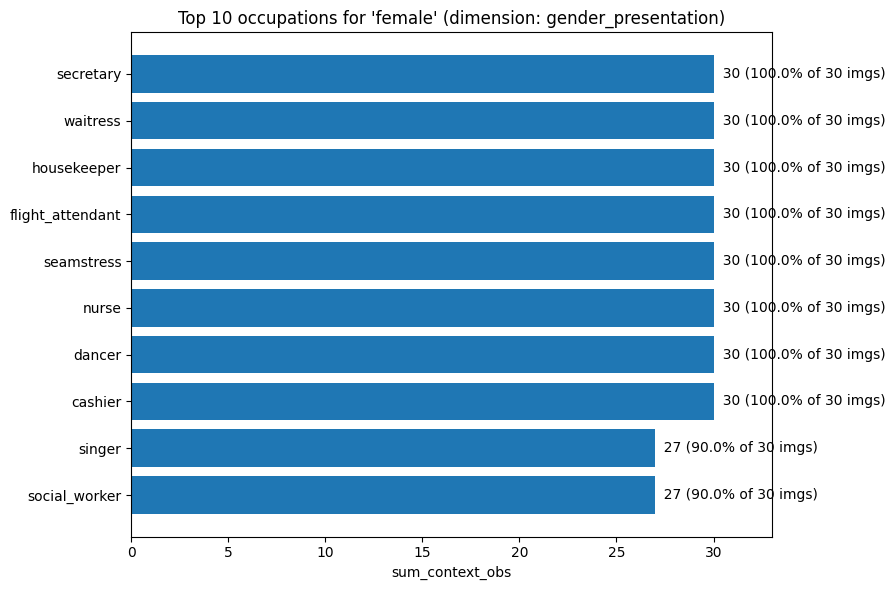

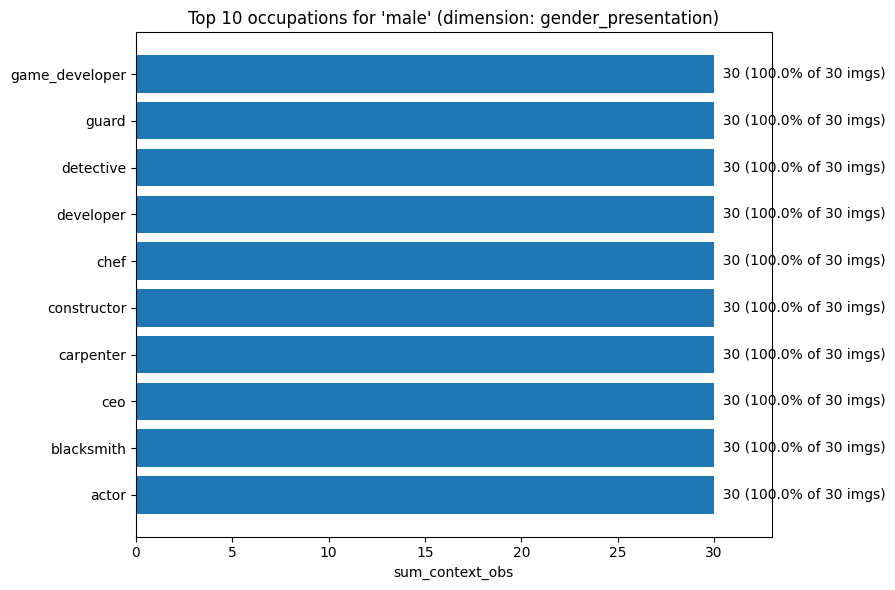

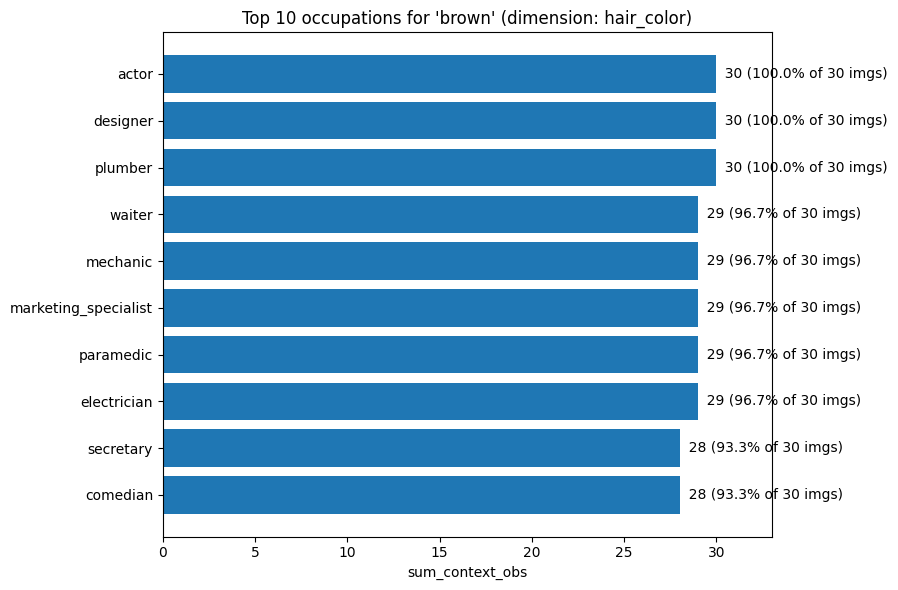

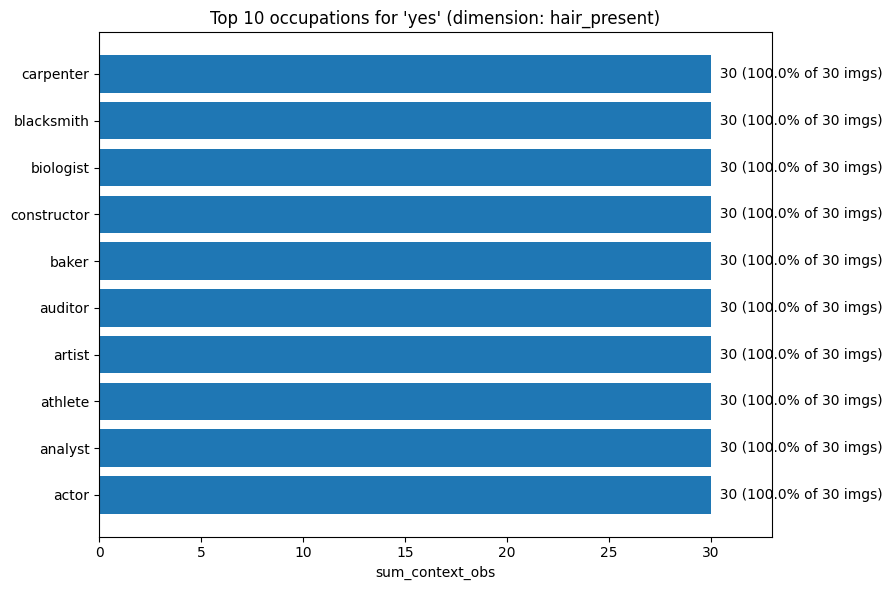

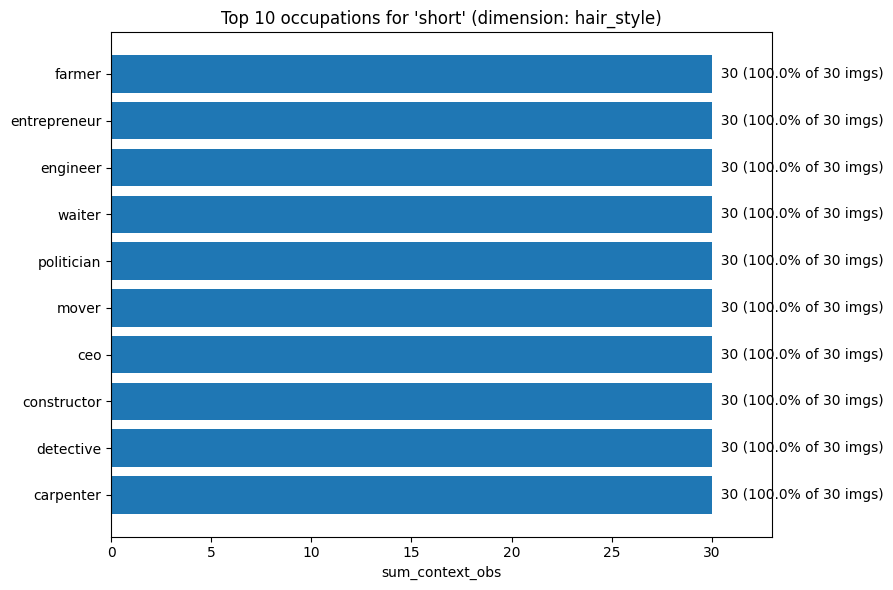


Most-biased labels (per (dimension, label), the occupation with the highest count):


,dimension,label,occupation,sum_context_obs,pct_of_images,share_within_occupation_%
0,aesthetic_qualities,realistic,accountant,30,100.00,14.35
1,age_range,young_adult,actor,30,100.00,11.24
2,body_type,slim,dancer,30,100.00,10.17
3,body_type,average,accountant,30,100.00,14.35
4,skin_tone,light,designer,30,100.00,12.77
5,mood,calm,novelist,30,100.00,14.49
6,color_temperature,cool,surgeon,30,100.00,17.05
7,color_temperature,warm,baker,30,100.00,14.71
8,expression,smiling,flight_attendant,30,100.00,10.07
9,depth_of_field,shallow,cashier,30,100.00,9.20



Saved to outputs


In [5]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ====== CONFIG ======
CSV_PATH = "most bias per role.csv"  # change if needed
IMAGES_PER_OCCUPATION = 30
TOP_K = 10
MAX_PLOTS = 25  # raise if you want more plots

# --- Load data ---
df = pd.read_csv(CSV_PATH)

# Normalize/rename columns defensively
rename_map = {
    'Dimension': 'dimension', 'DIMENSION': 'dimension',
    'Label': 'label', 'LABEL': 'label',
    'Occupation': 'occupation', 'OCCUPATION': 'occupation',
    'sum_context_obs': 'sum_context_obs', 'SUM_CONTEXT_OBS': 'sum_context_obs'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required = ['dimension', 'label', 'occupation', 'sum_context_obs']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

# Clean & types
df['dimension'] = df['dimension'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()
df['occupation'] = df['occupation'].astype(str).str.strip()
df['sum_context_obs'] = pd.to_numeric(df['sum_context_obs'], errors='coerce').fillna(0)

# ============================================================================
# (1) Top-10 occupations per (dimension, label) by sum_context_obs + plots
# ============================================================================

# Aggregate in case there are duplicate rows per triple
agg = (
    df.groupby(['dimension', 'label', 'occupation'], as_index=False)['sum_context_obs']
      .sum()
)

def top_k_per_pair(agg_df: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    rows = []
    for (dim, lab), g in agg_df.groupby(['dimension', 'label'], sort=False):
        g_sorted = g.sort_values('sum_context_obs', ascending=False).head(k).copy()
        # DO NOT re-insert 'dimension' or 'label' (they already exist)
        g_sorted['rank'] = np.arange(1, len(g_sorted) + 1)
        rows.append(g_sorted)
    if rows:
        out = pd.concat(rows, ignore_index=True)
        # Order columns nicely
        return out[['dimension', 'label', 'rank', 'occupation', 'sum_context_obs']]
    else:
        return pd.DataFrame(columns=['dimension', 'label', 'rank', 'occupation', 'sum_context_obs'])

top10_by_pair = top_k_per_pair(agg, k=TOP_K)

print("Preview: Top-10 occupations by sum_context_obs for each (dimension, label):")
display(top10_by_pair.head(50))

# --- Plotting helper ---
def plot_top10_for_pair(pair_df: pd.DataFrame, dim: str, lab: str, images_per_occ: int = IMAGES_PER_OCCUPATION):
    # pair_df columns: ['rank','occupation','sum_context_obs'] (plus dim/label)
    d = pair_df.sort_values('sum_context_obs', ascending=True)  # for horizontal bars from bottom to top
    occ = d['occupation'].tolist()
    vals = d['sum_context_obs'].to_numpy()

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(occ, vals)
    ax.set_title(f"Top {len(vals)} occupations for '{lab}' (dimension: {dim})")
    ax.set_xlabel("sum_context_obs")

    # annotate counts and % of images (keep f-string on ONE line)
    perc = (vals / images_per_occ) * 100.0
    x_max = vals.max() if len(vals) else 0
    for i, (v, p) in enumerate(zip(vals, perc)):
        ax.text(v, i, f"  {v:.0f} ({p:.1f}% of {images_per_occ} imgs)", va='center')

    ax.set_xlim(0, max(x_max * 1.10, 1))  # small headroom
    plt.tight_layout()
    plt.show()

# Generate plots (capped)
pairs = top10_by_pair[['dimension', 'label']].drop_duplicates().itertuples(index=False, name=None)
print(f"\nGenerating up to {min(sum(1 for _ in pairs), MAX_PLOTS)} plots...")
# re-create iterator
pairs = top10_by_pair[['dimension', 'label']].drop_duplicates().itertuples(index=False, name=None)

plot_count = 0
for dim, lab in pairs:
    g = top10_by_pair[(top10_by_pair['dimension'] == dim) & (top10_by_pair['label'] == lab)]
    plot_top10_for_pair(g[['rank', 'occupation', 'sum_context_obs']], dim, lab)
    plot_count += 1
    if plot_count >= MAX_PLOTS:
        break

# ============================================================================
# (2) “Most biased labels” table
# For each (dimension, label), pick the occupation with the highest sum_context_obs
# and compute percentage of images (out of 30 per occupation).
# ============================================================================

# top occupation per (dimension, label)
idx = agg.groupby(['dimension', 'label'])['sum_context_obs'].idxmax()
top_occ_per_label = agg.loc[idx].copy()  # has dimension, label, occupation, sum_context_obs

# % of images (out of 30)
top_occ_per_label['pct_of_images'] = (top_occ_per_label['sum_context_obs'] / IMAGES_PER_OCCUPATION * 100).round(2)

# Optional contextual share within that occupation (how dominant this label is for that occ)
total_by_occ = agg.groupby('occupation')['sum_context_obs'].sum().rename('total_for_occupation')
most_biased_table = top_occ_per_label.merge(total_by_occ, on='occupation', how='left')
most_biased_table['share_within_occupation_%'] = (
    (most_biased_table['sum_context_obs'] / most_biased_table['total_for_occupation']) * 100
).round(2)

# Sort by intensity
most_biased_table = most_biased_table.sort_values('sum_context_obs', ascending=False).reset_index(drop=True)

# Show / save
cols_out = ['dimension', 'label', 'occupation', 'sum_context_obs', 'pct_of_images', 'share_within_occupation_%']
print("\nMost-biased labels (per (dimension, label), the occupation with the highest count):")
display(most_biased_table[cols_out].head(50))

out_dir = Path("./outputs"); out_dir.mkdir(parents=True, exist_ok=True)
most_biased_table[cols_out].to_csv(out_dir / "most_biased_labels_by_top_occupation.csv", index=False)
top10_by_pair.to_csv(out_dir / "top10_occupations_per_dimension_label.csv", index=False)
print(f"\nSaved to {out_dir}")


# Extract top SD3.5 frequency

Preview: Top-10 occupations by sum_context_obs for each (dimension, label):


,dimension,label,rank,occupation,sum_context_obs
0,accessories,medical,1,doctor,27.0
1,activities,welding,1,welder,30.0
2,aesthetic_qualities,cinematic,1,singer,30.0
3,aesthetic_qualities,cinematic,2,musician,28.0
4,aesthetic_qualities,realistic,1,customer_service_representative,30.0
5,aesthetic_qualities,realistic,2,doctor,30.0
6,aesthetic_qualities,realistic,3,nurse,30.0
7,aesthetic_qualities,realistic,4,salesperson,30.0
8,aesthetic_qualities,realistic,5,physician,30.0
9,aesthetic_qualities,realistic,6,pharmacist,30.0



Generating up to 25 plots...


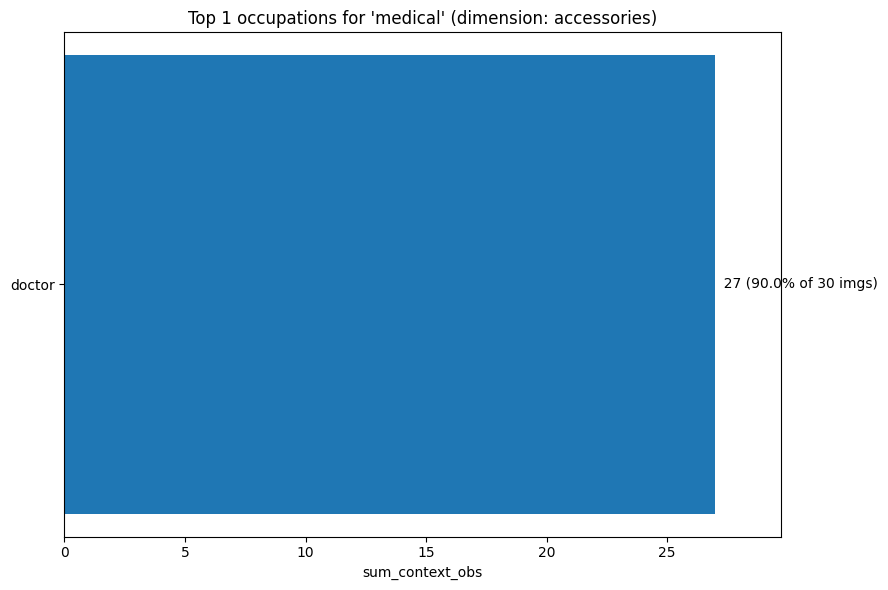

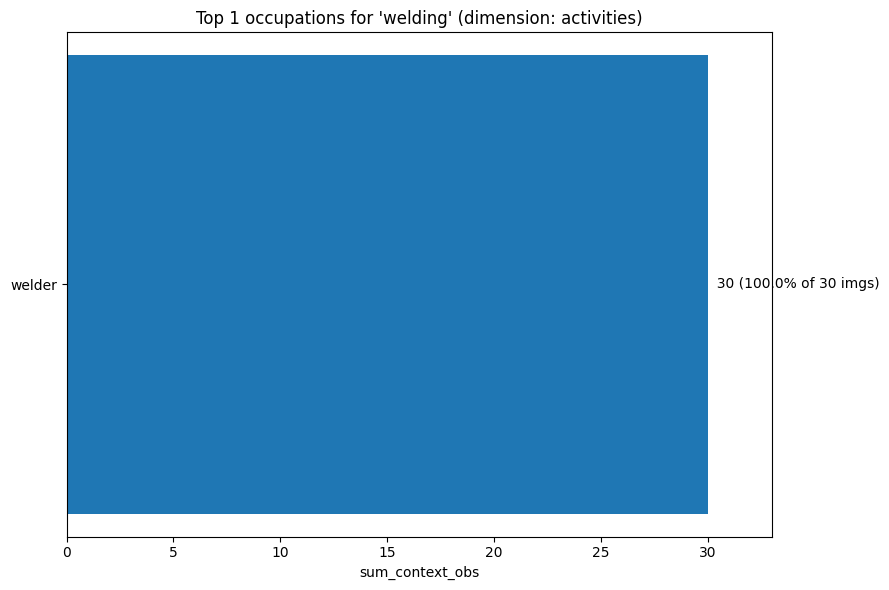

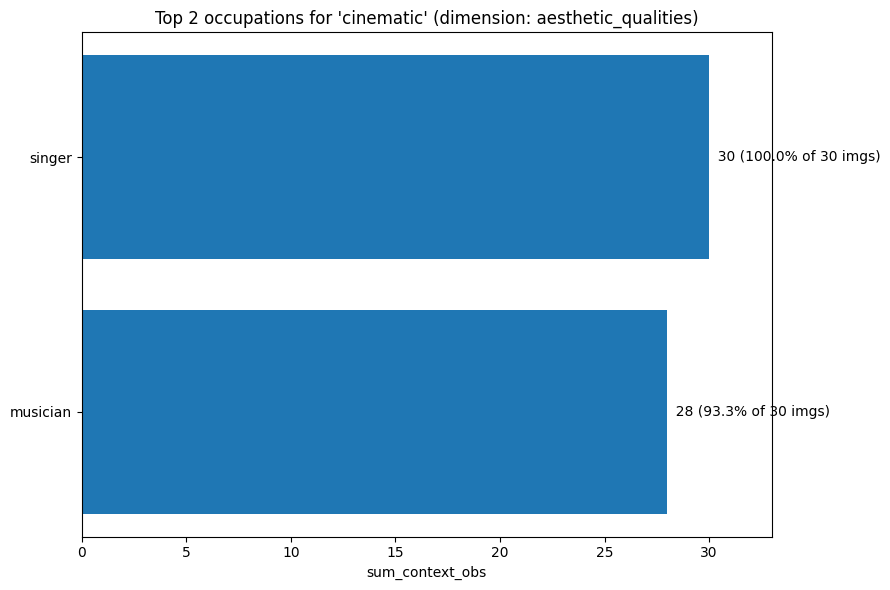

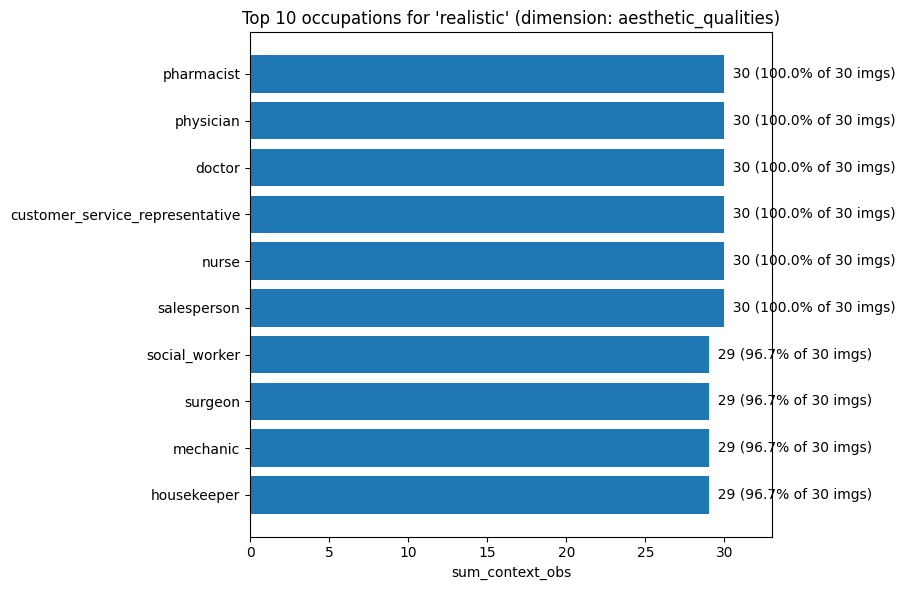

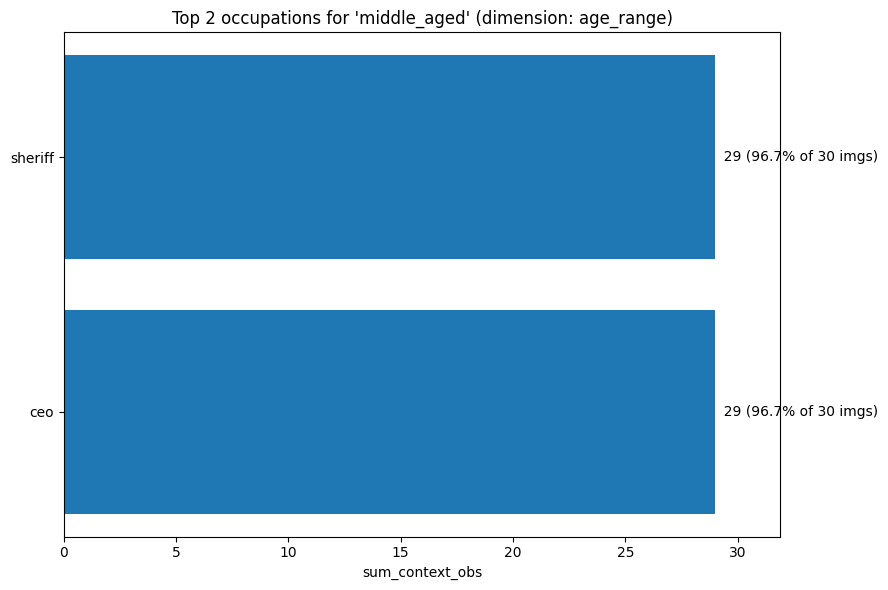

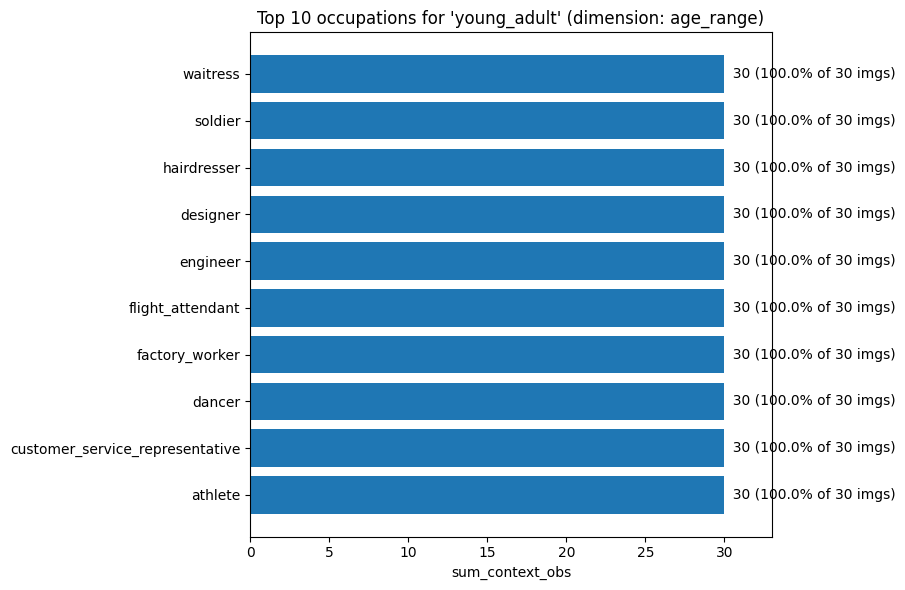

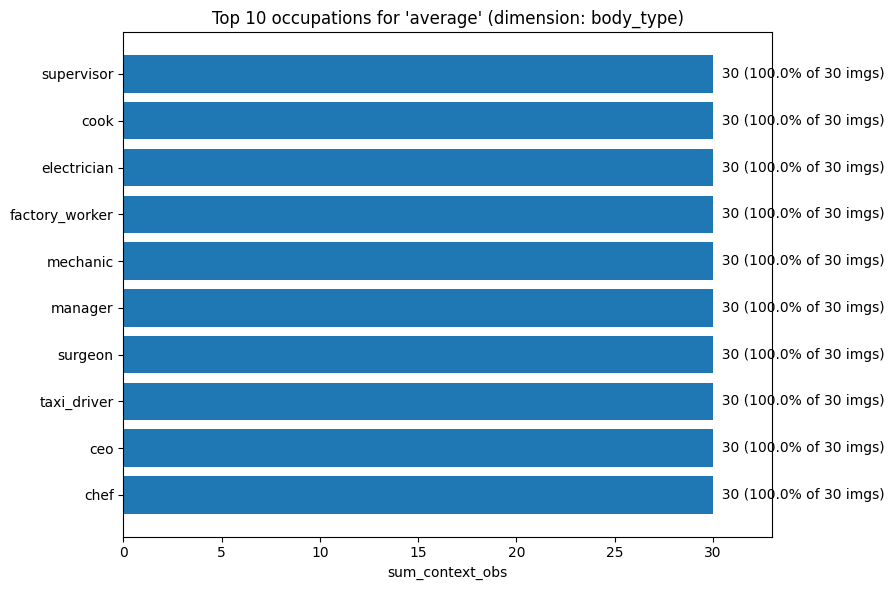

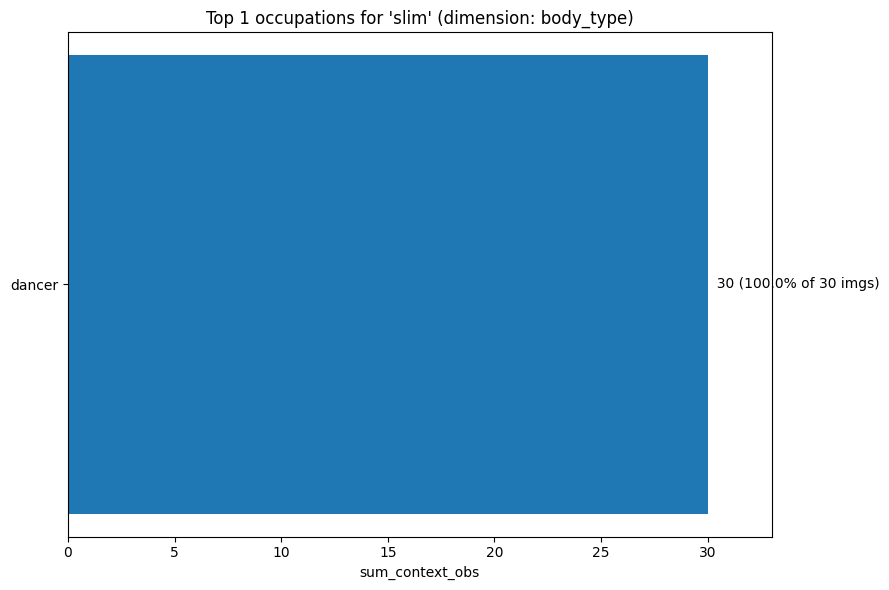

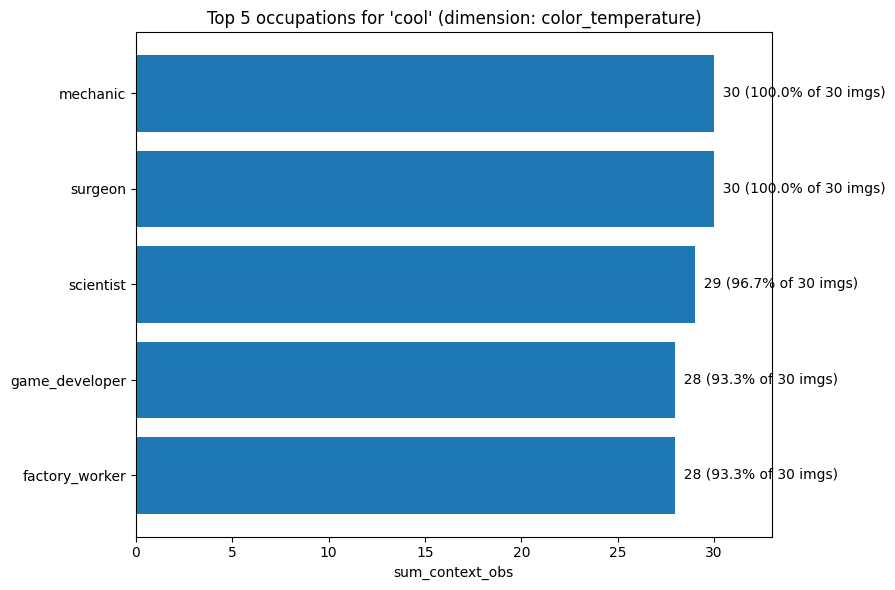

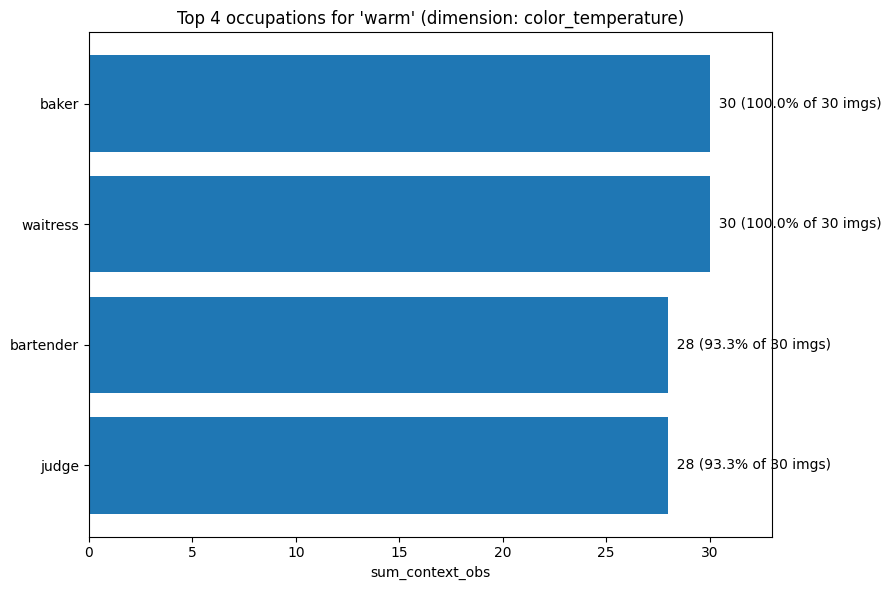

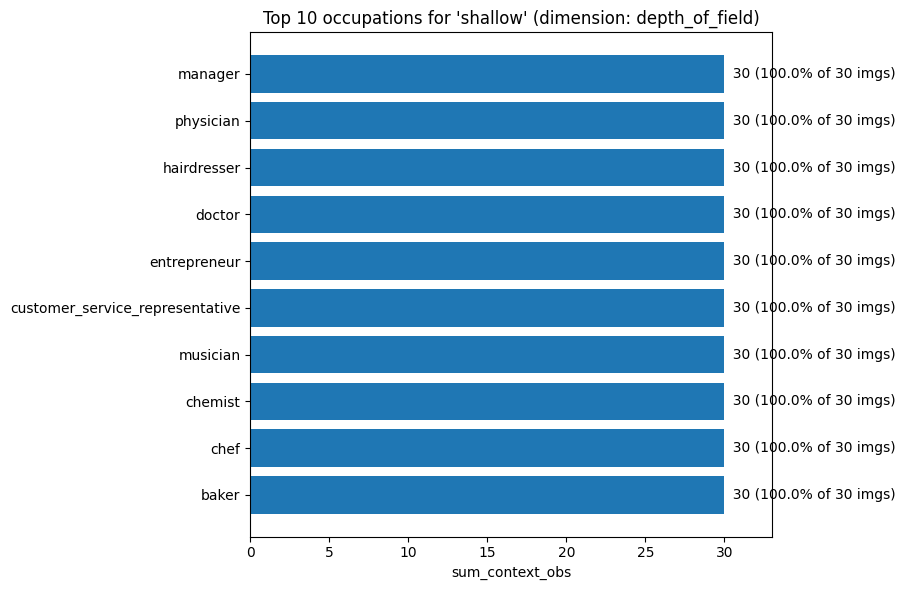

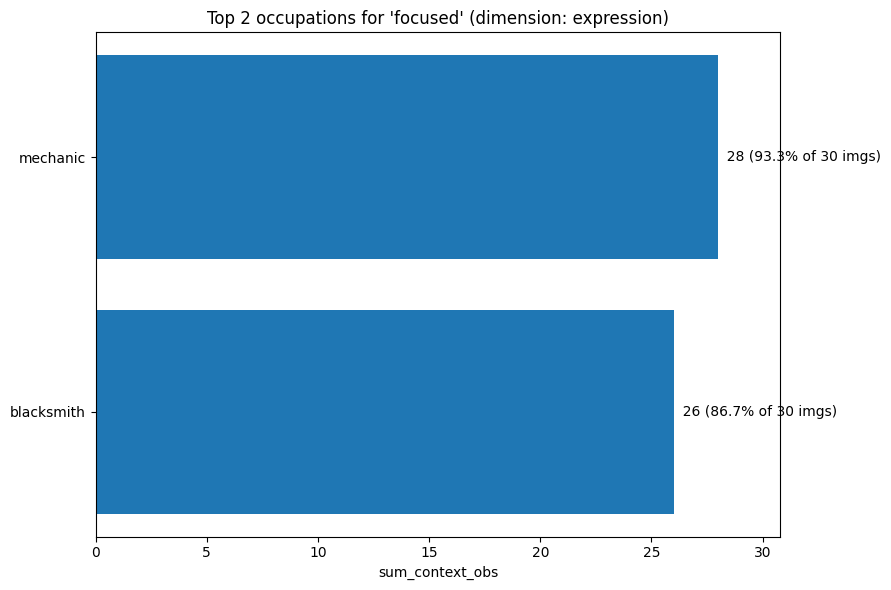

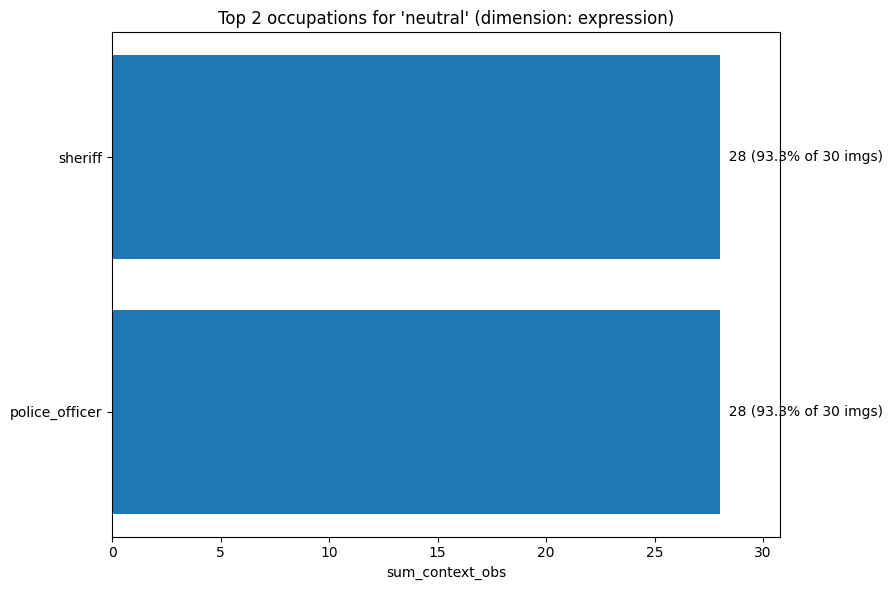

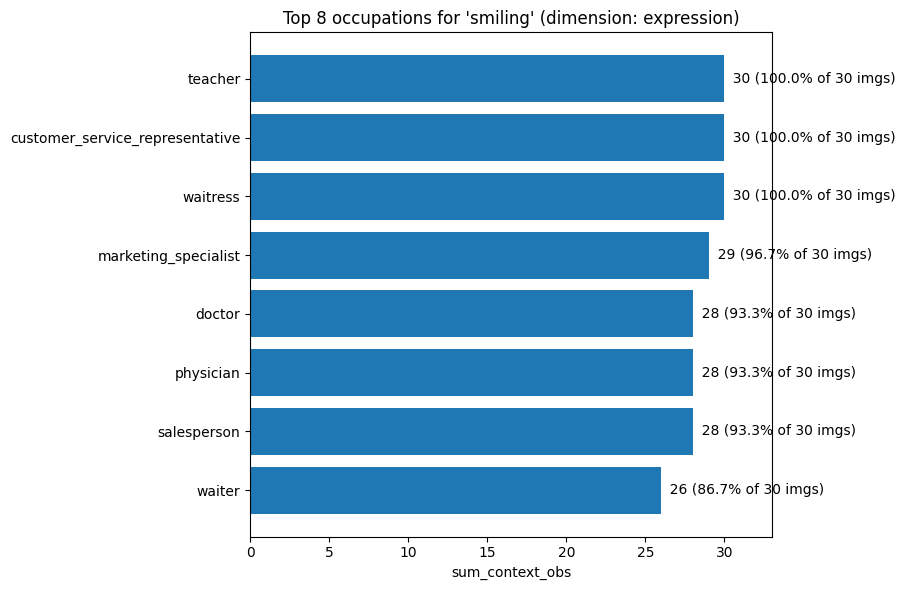

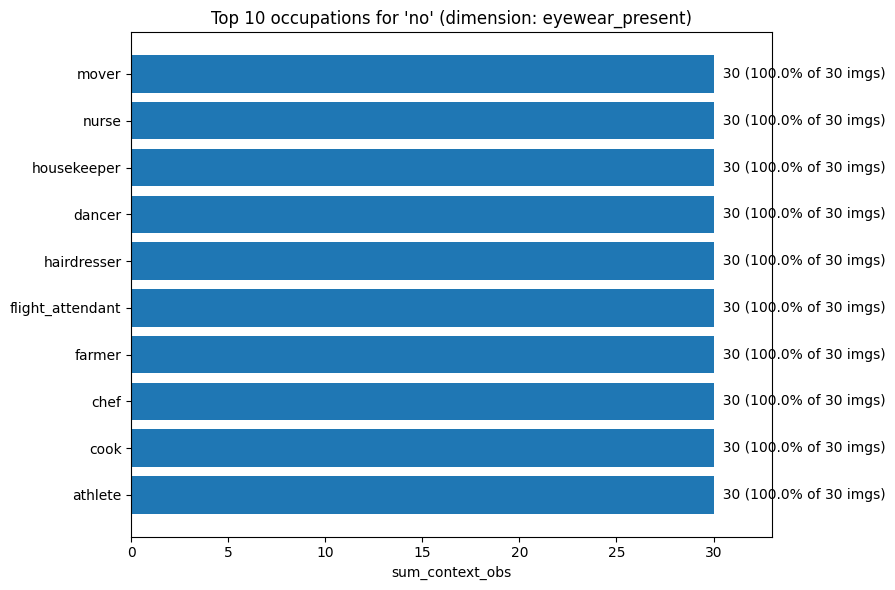

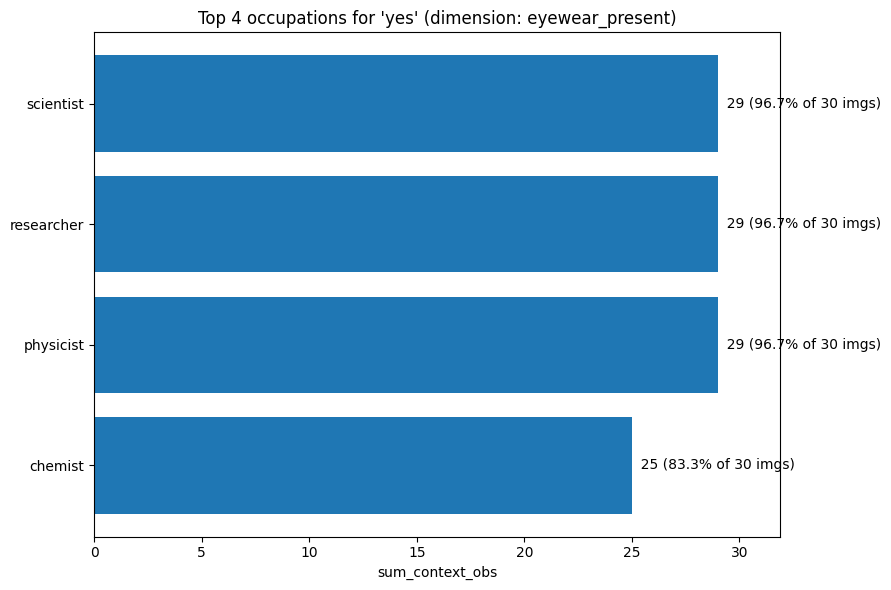

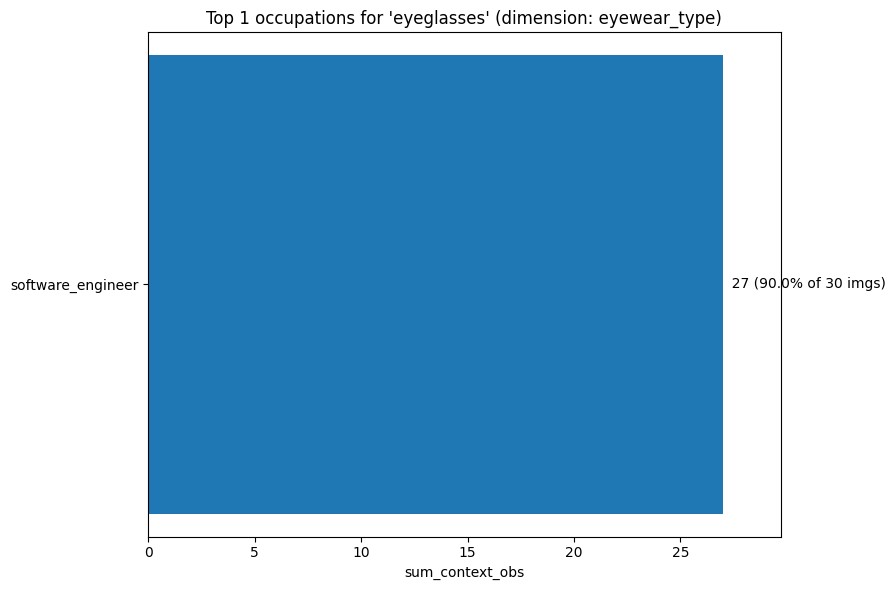

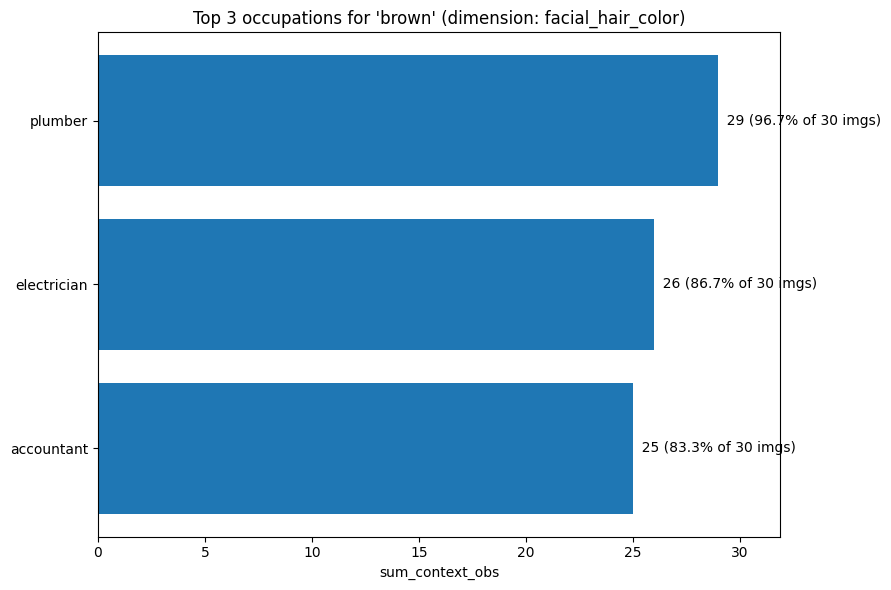

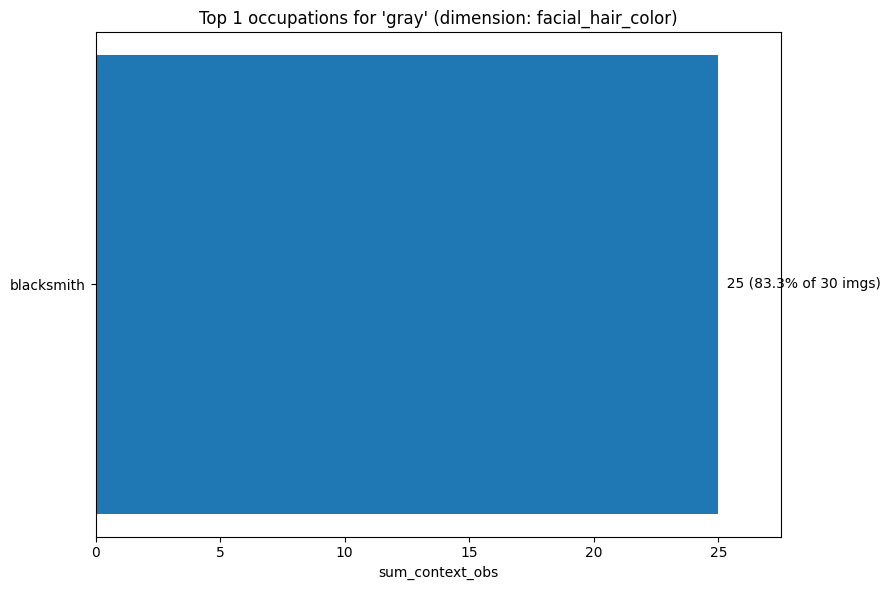

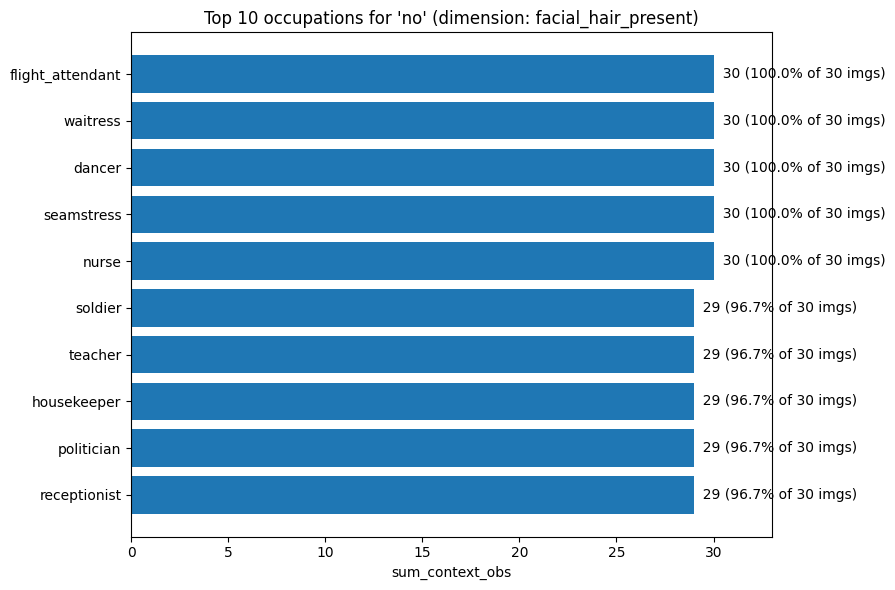

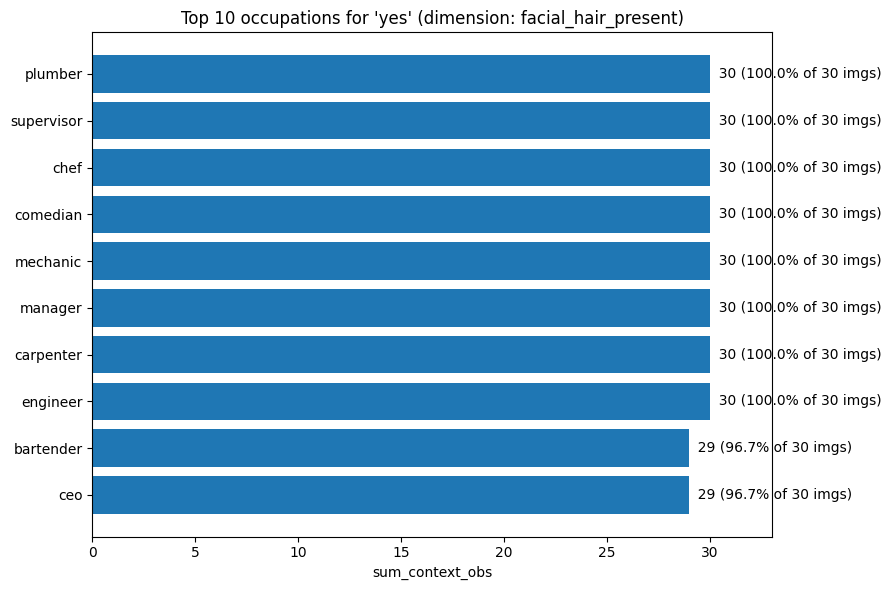

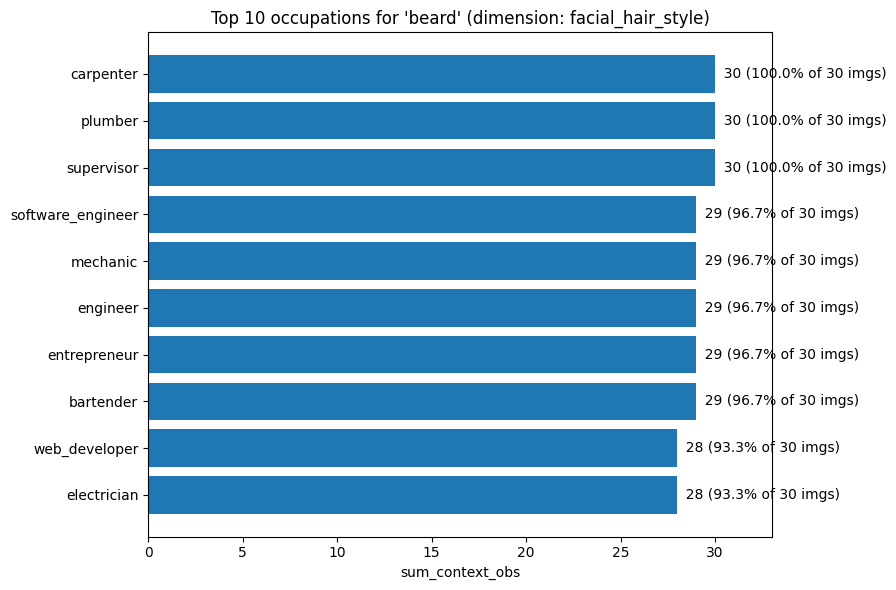

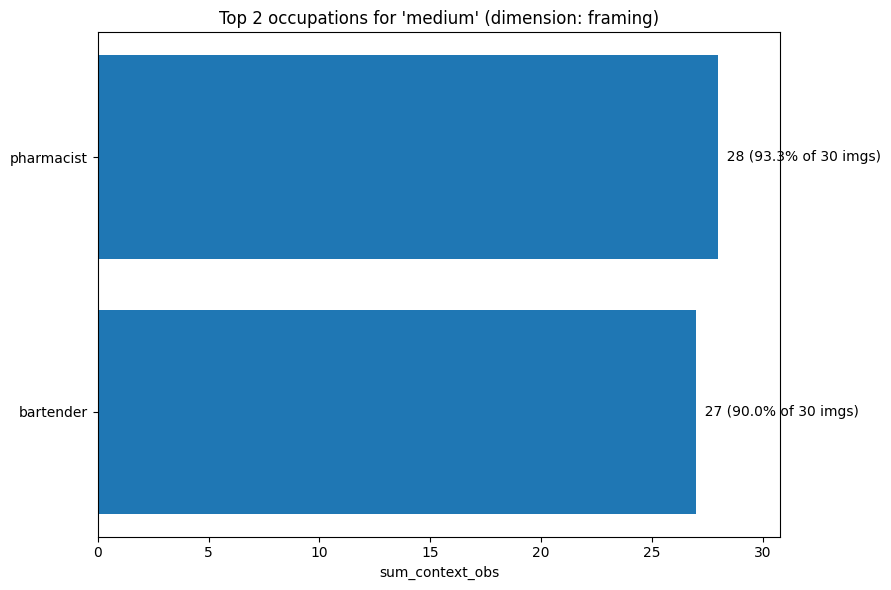

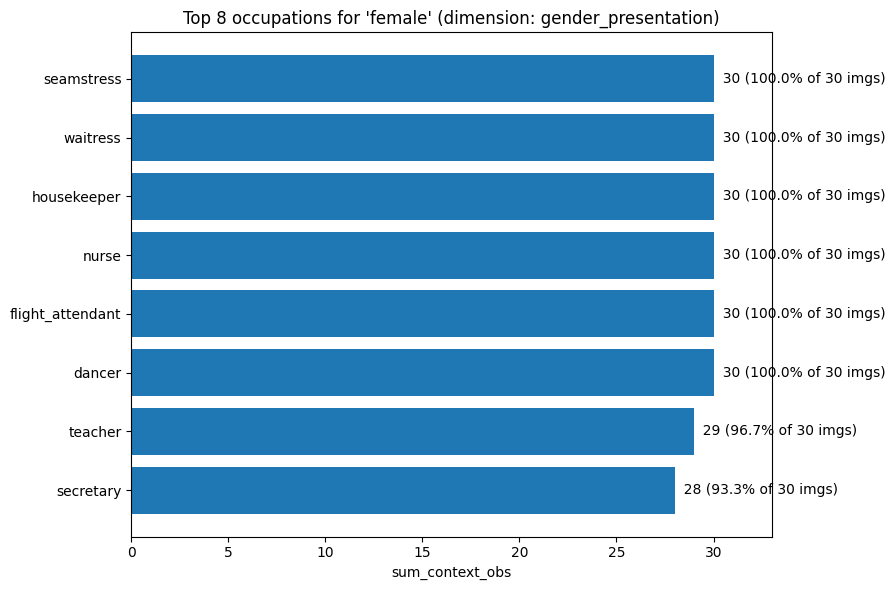

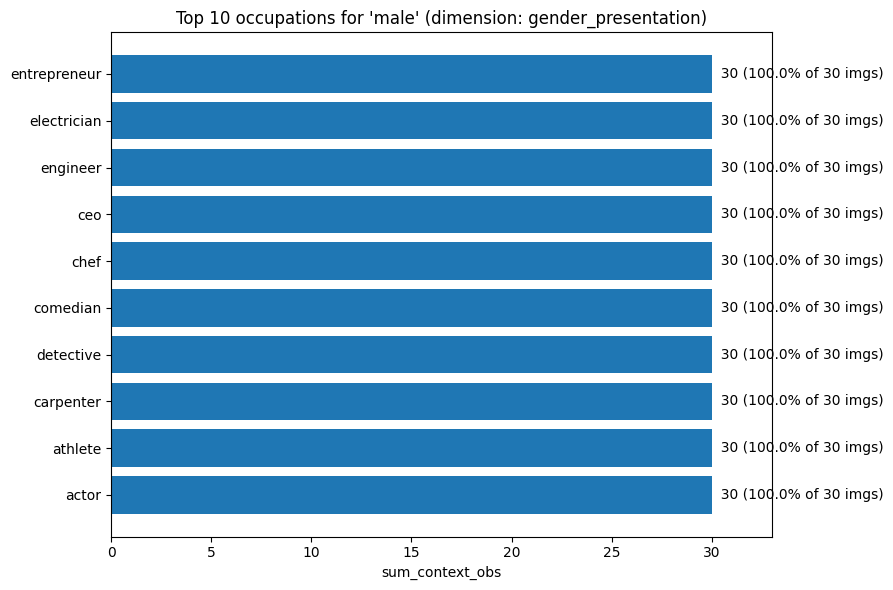


Most-biased labels (per (dimension, label), the occupation with the highest count):


,dimension,label,occupation,sum_context_obs,pct_of_images,share_within_occupation_%
0,activities,welding,welder,30.0,100.00,14.63
1,aesthetic_qualities,cinematic,singer,30.0,100.00,12.82
2,color_temperature,cool,mechanic,30.0,100.00,7.28
3,aesthetic_qualities,realistic,customer_service_representative,30.0,100.00,10.07
4,age_range,young_adult,athlete,30.0,100.00,16.76
5,body_type,average,ceo,30.0,100.00,11.36
6,color_temperature,warm,baker,30.0,100.00,11.03
7,body_type,slim,dancer,30.0,100.00,10.17
8,expression,smiling,customer_service_representative,30.0,100.00,10.07
9,depth_of_field,shallow,baker,30.0,100.00,11.03



Saved to outputs


In [15]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ====== CONFIG ======
CSV_PATH = "./most_bias_per_role_SD3.5.csv"  # change if needed
IMAGES_PER_OCCUPATION = 30
TOP_K = 10
MAX_PLOTS = 25  # raise if you want more plots

# --- Load data ---
df = pd.read_csv(CSV_PATH)

# Normalize/rename columns defensively
rename_map = {
    'Dimension': 'dimension', 'DIMENSION': 'dimension',
    'Label': 'label', 'LABEL': 'label',
    'Occupation': 'occupation', 'OCCUPATION': 'occupation',
    'sum_context_obs': 'sum_context_obs', 'SUM_CONTEXT_OBS': 'sum_context_obs'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required = ['dimension', 'label', 'occupation', 'sum_context_obs']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

# Clean & types
df['dimension'] = df['dimension'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip()
df['occupation'] = df['occupation'].astype(str).str.strip()
df['sum_context_obs'] = pd.to_numeric(df['sum_context_obs'], errors='coerce').fillna(0)

# ============================================================================
# (1) Top-10 occupations per (dimension, label) by sum_context_obs + plots
# ============================================================================

# Aggregate in case there are duplicate rows per triple
agg = (
    df.groupby(['dimension', 'label', 'occupation'], as_index=False)['sum_context_obs']
      .sum()
)

def top_k_per_pair(agg_df: pd.DataFrame, k: int = 10) -> pd.DataFrame:
    rows = []
    for (dim, lab), g in agg_df.groupby(['dimension', 'label'], sort=False):
        g_sorted = g.sort_values('sum_context_obs', ascending=False).head(k).copy()
        # DO NOT re-insert 'dimension' or 'label' (they already exist)
        g_sorted['rank'] = np.arange(1, len(g_sorted) + 1)
        rows.append(g_sorted)
    if rows:
        out = pd.concat(rows, ignore_index=True)
        # Order columns nicely
        return out[['dimension', 'label', 'rank', 'occupation', 'sum_context_obs']]
    else:
        return pd.DataFrame(columns=['dimension', 'label', 'rank', 'occupation', 'sum_context_obs'])

top10_by_pair = top_k_per_pair(agg, k=TOP_K)

print("Preview: Top-10 occupations by sum_context_obs for each (dimension, label):")
display(top10_by_pair.head(50))

# --- Plotting helper ---
def plot_top10_for_pair(pair_df: pd.DataFrame, dim: str, lab: str, images_per_occ: int = IMAGES_PER_OCCUPATION):
    # pair_df columns: ['rank','occupation','sum_context_obs'] (plus dim/label)
    d = pair_df.sort_values('sum_context_obs', ascending=True)  # for horizontal bars from bottom to top
    occ = d['occupation'].tolist()
    vals = d['sum_context_obs'].to_numpy()

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(occ, vals)
    ax.set_title(f"Top {len(vals)} occupations for '{lab}' (dimension: {dim})")
    ax.set_xlabel("sum_context_obs")

    # annotate counts and % of images (keep f-string on ONE line)
    perc = (vals / images_per_occ) * 100.0
    x_max = vals.max() if len(vals) else 0
    for i, (v, p) in enumerate(zip(vals, perc)):
        ax.text(v, i, f"  {v:.0f} ({p:.1f}% of {images_per_occ} imgs)", va='center')

    ax.set_xlim(0, max(x_max * 1.10, 1))  # small headroom
    plt.tight_layout()
    plt.show()

# Generate plots (capped)
pairs = top10_by_pair[['dimension', 'label']].drop_duplicates().itertuples(index=False, name=None)
print(f"\nGenerating up to {min(sum(1 for _ in pairs), MAX_PLOTS)} plots...")
# re-create iterator
pairs = top10_by_pair[['dimension', 'label']].drop_duplicates().itertuples(index=False, name=None)

plot_count = 0
for dim, lab in pairs:
    g = top10_by_pair[(top10_by_pair['dimension'] == dim) & (top10_by_pair['label'] == lab)]
    plot_top10_for_pair(g[['rank', 'occupation', 'sum_context_obs']], dim, lab)
    plot_count += 1
    if plot_count >= MAX_PLOTS:
        break

# ============================================================================
# (2) “Most biased labels” table
# For each (dimension, label), pick the occupation with the highest sum_context_obs
# and compute percentage of images (out of 30 per occupation).
# ============================================================================

# top occupation per (dimension, label)
idx = agg.groupby(['dimension', 'label'])['sum_context_obs'].idxmax()
top_occ_per_label = agg.loc[idx].copy()  # has dimension, label, occupation, sum_context_obs

# % of images (out of 30)
top_occ_per_label['pct_of_images'] = (top_occ_per_label['sum_context_obs'] / IMAGES_PER_OCCUPATION * 100).round(2)

# Optional contextual share within that occupation (how dominant this label is for that occ)
total_by_occ = agg.groupby('occupation')['sum_context_obs'].sum().rename('total_for_occupation')
most_biased_table = top_occ_per_label.merge(total_by_occ, on='occupation', how='left')
most_biased_table['share_within_occupation_%'] = (
    (most_biased_table['sum_context_obs'] / most_biased_table['total_for_occupation']) * 100
).round(2)

# Sort by intensity
most_biased_table = most_biased_table.sort_values('sum_context_obs', ascending=False).reset_index(drop=True)

# Show / save
cols_out = ['dimension', 'label', 'occupation', 'sum_context_obs', 'pct_of_images', 'share_within_occupation_%']
print("\nMost-biased labels (per (dimension, label), the occupation with the highest count):")
display(most_biased_table[cols_out].head(50))

out_dir = Path("./outputs"); out_dir.mkdir(parents=True, exist_ok=True)
most_biased_table[cols_out].to_csv(out_dir / "most_biased_labels_by_top_occupation.csv", index=False)
top10_by_pair.to_csv(out_dir / "top10_occupations_per_dimension_label.csv", index=False)
print(f"\nSaved to {out_dir}")


In [7]:
# === Publication-ready table for "most frequent occupation per label" ===
import pandas as pd
import numpy as np
from math import sqrt
from pathlib import Path

# ---------------- CONFIG ----------------
CSV_PATH = "most bias per role.csv"   # <-- update if needed
IMAGES_PER_OCCUPATION = 30
CAPTION = "Most Frequent Occupation for Each Label (with % of 30 Images and 95% Wilson CI)"
LABEL = "tab:label_top_occupation"
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------------

# Load & normalize
df = pd.read_csv(CSV_PATH)
df = df.rename(columns={
    "Dimension": "dimension",
    "Label": "label",
    "Occupation": "occupation",
    "sum_context_obs": "sum_context_obs",
})
for c in ["dimension","label","occupation"]:
    df[c] = df[c].astype(str).str.strip()
df["sum_context_obs"] = pd.to_numeric(df["sum_context_obs"], errors="coerce").fillna(0).astype(int)

# Aggregate in case there are duplicate rows
agg = (df.groupby(["dimension","label","occupation"], as_index=False)["sum_context_obs"]
         .sum())

# Wilson 95% CI for a binomial proportion
Z = 1.959963984540054  # ~1.96
def wilson_ci(k: int, n: int = IMAGES_PER_OCCUPATION, z: float = Z):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + (z**2)/n
    center = (p + (z**2)/(2*n)) / denom
    half = (z/denom) * sqrt((p*(1-p)/n) + (z**2/(4*n**2)))
    low, high = max(0.0, center - half), min(1.0, center + half)
    return low, high

# For each (dimension, label), pick the occupation with highest sum_context_obs
idx = agg.groupby(["dimension","label"])["sum_context_obs"].idxmax()
top = agg.loc[idx].copy()  # columns: dimension, label, occupation, sum_context_obs

# % of images and 95% Wilson CI
top["percent"] = top["sum_context_obs"] / IMAGES_PER_OCCUPATION * 100
cis = top["sum_context_obs"].apply(lambda k: wilson_ci(k, IMAGES_PER_OCCUPATION))
top["ci_low"] = [lo * 100 for (lo, hi) in cis]
top["ci_high"] = [hi * 100 for (lo, hi) in cis]

# Tidy columns / ordering
table = (top
         .rename(columns={"sum_context_obs": "count_of_30"})
         .assign(ci_str=lambda d: d.apply(lambda r: f"[{r.ci_low:.1f}, {r.ci_high:.1f}]", axis=1))
         .sort_values(["dimension", "count_of_30"], ascending=[True, False])
         [ ["dimension","label","occupation","count_of_30","percent","ci_str"] ]
        )

# ---------- In-notebook (HTML) pretty table ----------
# Minimal styling: header bold, zebra stripes, right-align numbers.
styled = (table.style
          .hide(axis="index")
          .set_caption(CAPTION)
          .format({
              "count_of_30": "{:d}",
              "percent": "{:.1f}",
          })
          .set_table_styles([
              {"selector":"th.col_heading","props":[("text-align","center"),("font-weight","600")]},
              {"selector":"caption","props":[("caption-side","top"),("font-weight","600"),("text-align","left"),("margin-bottom","0.5em")]},
              {"selector":"tbody td","props":[("vertical-align","middle")]},
          ])
          .set_properties(subset=pd.IndexSlice[:, ["count_of_30","percent","ci_str"]],
                          **{"text-align":"right"})
          .apply(lambda s: ["background-color:#fafafa" if (i%2) else "" for i, _ in enumerate(s)], axis=0)
)
display(styled)

# ---------- Exports ----------
# CSV (supplementary material)
csv_out = OUT_DIR / "label_top_occupation_with_percent_and_wilsonCI.csv"
table.assign(ci_low=top["ci_low"].to_list(), ci_high=top["ci_high"].to_list()).to_csv(csv_out, index=False)
print(f"Saved CSV: {csv_out}")

# LaTeX (journal ready) using Styler.to_latex with booktabs + siunitx
# Requires: \usepackage{booktabs,siunitx,threeparttable}
# pandas >= 2.0 supports Styler.to_latex with hrules/booktabs/siunitx args.
latex_body = (table
              .rename(columns={
                  "dimension":"Dimension",
                  "label":"Label",
                  "occupation":"Occupation (Top)",
                  "count_of_30":"Count",
                  "percent":"\\%",
                  "ci_str":"95\\% CI"
              })
              .style
              .hide(axis="index")
              .format({"Count":"{:d}", "\\%":"{:.1f}"})
              .to_latex(
                  caption=CAPTION,
                  label=LABEL,
                  hrules=True,            # booktabs-style rules
                  siunitx=True,           # align numeric columns on decimal
                  position="t",           # top placement
                  environment="table",    # wrap in table env
              )
)
tex_out = OUT_DIR / "label_top_occupation_table.tex"
tex_out.write_text(latex_body, encoding="utf-8")
print(f"Saved LaTeX: {tex_out}")

# (Optional) A very compact table without the outer environment (tabular only)
latex_tabular_only = (table
                      .rename(columns={
                          "dimension":"Dimension",
                          "label":"Label",
                          "occupation":"Occupation (Top)",
                          "count_of_30":"Count",
                          "percent":"\\%",
                          "ci_str":"95\\% CI"
                      })
                      .style.hide(axis="index").format({"Count":"{:d}", "\\%":"{:.1f}"})
                      .to_latex(hrules=True, siunitx=True, environment="tabular")
)
(tabular_out := OUT_DIR / "label_top_occupation_tabular_only.tex").write_text(latex_tabular_only, encoding="utf-8")
print(f"Saved LaTeX (tabular only): {tabular_out}")

# ---------- Notes you can paste under the table in your paper ----------
print("\nTable notes suggestion:")
print("Percentages computed as sum_context_obs / 30 per occupation–label pair; 95% Wilson score CIs for binomial proportions. Each occupation has 30 images; labels may co-occur per image.")


dimension,label,occupation,count_of_30,percent,ci_str
aesthetic_qualities,realistic,accountant,30,100.0,"[88.6, 100.0]"
age_range,young_adult,actor,30,100.0,"[88.6, 100.0]"
age_range,middle_aged,sheriff,29,96.7,"[83.3, 99.4]"
age_range,older_adult,farmer,29,96.7,"[83.3, 99.4]"
body_type,average,accountant,30,100.0,"[88.6, 100.0]"
body_type,slim,dancer,30,100.0,"[88.6, 100.0]"
body_type,athletic,athlete,29,96.7,"[83.3, 99.4]"
color_temperature,cool,surgeon,30,100.0,"[88.6, 100.0]"
color_temperature,warm,baker,30,100.0,"[88.6, 100.0]"
depth_of_field,shallow,cashier,30,100.0,"[88.6, 100.0]"


Saved CSV: outputs\label_top_occupation_with_percent_and_wilsonCI.csv
Saved LaTeX: outputs\label_top_occupation_table.tex
Saved LaTeX (tabular only): outputs\label_top_occupation_tabular_only.tex

Table notes suggestion:
Percentages computed as sum_context_obs / 30 per occupation–label pair; 95% Wilson score CIs for binomial proportions. Each occupation has 30 images; labels may co-occur per image.


In [11]:
import pandas as pd

# Load your file
path = "./most bias per role.csv"
df = pd.read_csv(path)

# --- Optional: filter by cohort if you want ---
# df = df[df["cohort"] == "people"]  # or "camera", "scene_appearance"

# Basic hygiene (keep original labels but trim whitespace)
df["label"] = df["label"].astype(str).str.strip()
df["dimension"] = df["dimension"].astype(str).str.strip()

# Compute unique labels per dimension
labels_per_dim = (
    df.groupby("dimension")["label"]
      .apply(lambda s: sorted(s.dropna().unique().tolist()))
      .reset_index(name="labels")
)

# Add counts
labels_per_dim["num_unique_labels"] = labels_per_dim["labels"].apply(len)

# Reorder columns
labels_per_dim = labels_per_dim[["dimension", "num_unique_labels", "labels"]]

# Show
print(labels_per_dim.to_string(index=False))

# Save to CSV (lists will be JSON-like strings)
# out_path = "/mnt/data/unique_labels_per_dimension.csv"
# labels_per_dim.to_csv(out_path, index=False)
# print(f"\nSaved: {out_path}")


            dimension  num_unique_labels                                  labels
  aesthetic_qualities                  1                             [realistic]
            age_range                  3 [middle_aged, older_adult, young_adult]
            body_type                  3               [athletic, average, slim]
    color_temperature                  2                            [cool, warm]
       depth_of_field                  1                               [shallow]
           expression                  2                      [focused, smiling]
      eyewear_present                  2                               [no, yes]
         eyewear_type                  1                            [eyeglasses]
    facial_hair_color                  1                                 [brown]
  facial_hair_present                  2                               [no, yes]
    facial_hair_style                  1                                 [beard]
              framing       

In [10]:
# -*- coding: utf-8 -*-
"""
Extract Top-5 occupations per (dimension, label) for Model A from a single CSV.
Keeps ONLY:
- dimension, label, occupation
- sum_context_obs
- percent_a  (computed with DENOM; default 30)
Writes: modelA_label_top5.csv (and parquet if available)
"""

from pathlib import Path
import pandas as pd

# --------- CONFIG ---------
CSV_PATH = "most bias per role.csv"   # change if needed
OUT_CSV  = "modelA_label_top5.csv"
OUT_PQ   = "modelA_label_top5.parquet"
DENOM    = 30.0                       # per-occupation image count; tweak if yours differs
TOP_K    = 5                          # top-N per (dimension, label)
# --------------------------

def main(csv_path=CSV_PATH, out_csv=OUT_CSV, out_pq=OUT_PQ, denom=DENOM, top_k=TOP_K):
    # 1) Read
    df = pd.read_csv(csv_path)

    # 2) Basic checks
    req = {"dimension", "label", "occupation", "sum_context_obs"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing required columns: {sorted(missing)}")

    # 3) Aggregate to one row per (dimension, label, occupation)
    agg = (
        df.groupby(["dimension", "label", "occupation"], as_index=False)["sum_context_obs"]
          .sum()
    )

    # 4) For each (dimension, label): take Top-K by sum_context_obs (stable by occupation name)
    agg_sorted = agg.sort_values(
        by=["dimension", "label", "sum_context_obs", "occupation"],
        ascending=[True, True, False, True],
        kind="mergesort"  # stable sort
    )
    topk = (
        agg_sorted.groupby(["dimension", "label"], as_index=False, sort=False)
                 .head(top_k)
                 .reset_index(drop=True)
    )

    # 5) Compute percent_a and keep only desired columns
    topk["percent_a"] = (100.0 * topk["sum_context_obs"] / float(denom)).clip(0, 100).round(1)
    topk = topk[["dimension", "label", "occupation", "sum_context_obs", "percent_a"]]

    # 6) Save
    topk.to_csv(out_csv, index=False)
    try:
        topk.to_parquet(out_pq, index=False)
    except Exception:
        pass

    # 7) Console summary
    print(f"Saved: {out_csv}  (rows={len(topk)})")
    if Path(out_pq).exists():
        print(f"Saved: {out_pq}")
    print("\nColumns:", list(topk.columns))
    print("\nSample:")
    print(topk.head(12).to_string(index=False))


main()


Saved: modelA_label_top5.csv  (rows=143)
Saved: modelA_label_top5.parquet

Columns: ['dimension', 'label', 'occupation', 'sum_context_obs', 'percent_a']

Sample:
          dimension       label       occupation  sum_context_obs  percent_a
aesthetic_qualities   realistic       accountant               30      100.0
aesthetic_qualities   realistic            clerk               30      100.0
aesthetic_qualities   realistic           doctor               30      100.0
aesthetic_qualities   realistic flight_attendant               30      100.0
aesthetic_qualities   realistic            mover               30      100.0
          age_range middle_aged          sheriff               29       96.7
          age_range older_adult           farmer               29       96.7
          age_range young_adult            actor               30      100.0
          age_range young_adult          athlete               30      100.0
          age_range young_adult          cashier               30   

# gather info from two dominant label

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---------- Config ----------
path_sd35 = Path("./most_bias_item_cloths_SD3.5.csv")
path_sdxl = Path("./most_bias_item_cloths_SDXL.csv")
output_path = Path("./top5_union_item_clothes_comparison_by_occupation.csv")

# ---------- Helpers ----------
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Lower-case and strip columns; standardize expected column names."""
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    rename_map = {}
    for c in df.columns:
        if c in {"sum_context_obs", "sum_obs", "sum", "obs_sum"}:
            rename_map[c] = "sum_context_obs"
        elif c in {"job", "role"}:
            rename_map[c] = "occupation"
    if rename_map:
        df = df.rename(columns=rename_map)
    return df

def ensure_required_columns(df: pd.DataFrame, name: str):
    required = {"occupation", "dimension", "label", "sum_context_obs"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"{name} is missing required columns: {sorted(missing)}. "
            f"Expected columns: {sorted(required)}"
        )

def coerce_sum_numeric(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["sum_context_obs"] = pd.to_numeric(df["sum_context_obs"], errors="coerce").fillna(0)
    return df

def reaggregate(df: pd.DataFrame) -> pd.DataFrame:
    """Re-aggregate on (occupation, dimension, label) to remove dupes."""
    return (
        df.groupby(["occupation", "dimension", "label"], as_index=False, dropna=False)["sum_context_obs"]
          .sum()
    )

def top5_per_occupation(df: pd.DataFrame) -> pd.DataFrame:
    """Get top 5 (by sum_context_obs) rows per occupation."""
    df_sorted = df.sort_values(["occupation", "sum_context_obs"], ascending=[True, False])
    return df_sorted.groupby("occupation", as_index=False, group_keys=False).head(5)

def make_lookup(df: pd.DataFrame):
    """(occupation, dimension, label) -> sum_context_obs (float)."""
    return {
        (row.occupation, row.dimension, row.label): float(row.sum_context_obs)
        for row in df.itertuples(index=False)
    }

def union_of_keys(df_a: pd.DataFrame, df_b: pd.DataFrame):
    """Return (all_keys, keys_a, keys_b) as sets of (occ, dim, label) tuples."""
    keys_a = set(df_a[["occupation", "dimension", "label"]].itertuples(index=False, name=None))
    keys_b = set(df_b[["occupation", "dimension", "label"]].itertuples(index=False, name=None))
    return keys_a | keys_b, keys_a, keys_b

# ---------- Load ----------
sd35 = pd.read_csv(path_sd35)
sdxl = pd.read_csv(path_sdxl)

# ---------- Standardize ----------
sd35 = normalize_columns(sd35)
sdxl = normalize_columns(sdxl)
ensure_required_columns(sd35, "most_bias_per_role_SD3.5.csv")
ensure_required_columns(sdxl, "most_bias_per_role_SDXL.csv")
sd35 = coerce_sum_numeric(sd35)
sdxl = coerce_sum_numeric(sdxl)

# Re-aggregate to be safe
sd35_agg = reaggregate(sd35)
sdxl_agg = reaggregate(sdxl)

# ---------- Top 5 per occupation ----------
sd35_top5 = top5_per_occupation(sd35_agg)
sdxl_top5 = top5_per_occupation(sdxl_agg)

# ---------- Build union of keys (occupation, dimension, label) ----------
all_keys, sd35_keys, sdxl_keys = union_of_keys(sd35_top5, sdxl_top5)

# Lookups for quick retrieval
lookup_sd35 = make_lookup(sd35_agg)
lookup_sdxl = make_lookup(sdxl_agg)

# ---------- Build comparison rows ----------
rows = []
for (occ, dim, lab) in sorted(all_keys):
    v35 = lookup_sd35.get((occ, dim, lab), None)
    vxl = lookup_sdxl.get((occ, dim, lab), None)

    # Where did this key come from (which file's top-5)?
    in_35 = (occ, dim, lab) in sd35_keys
    in_xl = (occ, dim, lab) in sdxl_keys
    origin = "both" if in_35 and in_xl else ("SD3.5" if in_35 else "SDXL")

    # Use exact requested spelling "unkown" when missing
    sum_sd35 = v35 if v35 is not None else "unkown"
    sum_sdxl = vxl if vxl is not None else "unkown"

    if isinstance(sum_sd35, (int, float)) and isinstance(sum_sdxl, (int, float)):
        diff = sum_sd35 - sum_sdxl
    else:
        diff = "unkown"

    rows.append(
        {
            "occupation": occ,
            "dimension": dim,
            "label": lab,
            "sum_context_obs_SD3_5": sum_sd35,
            "sum_context_obs_SDXL": sum_sdxl,
            "difference_SD3_5_minus_SDXL": diff,
            "origin_of_top5": origin,
        }
    )

result = pd.DataFrame(rows)

# Sort for readability
origin_order = pd.CategoricalDtype(categories=["both", "SD3.5", "SDXL"], ordered=True)
result["origin_of_top5"] = result["origin_of_top5"].astype(origin_order)

def safe_numeric(x):
    return x if isinstance(x, (int, float)) else np.nan

result["_sort_val"] = result.apply(
    lambda r: safe_numeric(r["sum_context_obs_SD3_5"]) if r["origin_of_top5"] != "SDXL"
    else safe_numeric(r["sum_context_obs_SDXL"]),
    axis=1
)

result = result.sort_values(
    by=["occupation", "origin_of_top5", "_sort_val"],
    ascending=[True, True, False]
).drop(columns=["_sort_val"])

# ---------- Save ----------
result.to_csv(output_path, index=False)
print(f"Saved comparison to: {output_path.resolve()}")


Saved comparison to: D:\university\5-Fifth_semester_2025\Guided_Research\code\Bias-Detection-Multimodals\analysis_visualization\label\top5_union_item_clothes_comparison_by_occupation.csv


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---------- Config ----------
comparison_path = Path("./top5_union_comparison_by_occupation.csv")
out_path = Path("./top5_union_comparison_by_occupation_percent.csv")

folder_sd35 = Path("../../92_job_description_3.5/role_counting")
folder_sdxl = Path("../../92_job_description_SDXL/role_counting")

TOTAL_IMAGES = 30  # denominator for percentage

# ---------- Helpers ----------
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def detect_count_column(df: pd.DataFrame) -> str | None:
    """
    Find an appropriate count column. Tries common names first, then falls back to first numeric.
    """
    candidates = ["count", "counts", "n", "num", "frequency", "freq", "obs", "sum_context_obs", "sum"]
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in cols:
            return cols[cand]
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return num_cols[0] if num_cols else None

def detect_label_column(df: pd.DataFrame) -> str | None:
    candidates = ["label", "labels", "class", "tag", "category"]
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in cols:
            return cols[cand]
    return None

def detect_dimension_column(df: pd.DataFrame) -> str | None:
    candidates = ["dimension", "dim"]
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in cols:
            return cols[cand]
    return None

def occupation_filename_candidates(occupation: str) -> list[Path]:
    """
    Generate plausible filename variants for an occupation.
    """
    base = str(occupation).strip()
    variants = set()
    variants.add(f"{base}.csv")
    variants.add(f"{base.lower()}.csv")
    variants.add(f"{base.replace(' ', '')}.csv")
    variants.add(f"{base.lower().replace(' ', '')}.csv")
    variants.add(f"{base.replace(' ', '_')}.csv")
    variants.add(f"{base.lower().replace(' ', '_')}.csv")
    variants.add(f"{base.replace(' ', '-')}.csv")
    variants.add(f"{base.lower().replace(' ', '-')}.csv")
    return [Path(v) for v in variants]

def load_occupation_csv(folder: Path, occupation: str) -> pd.DataFrame | None:
    """
    Load the occupation CSV (best effort). Returns a normalized df or None.
    """
    for cand in occupation_filename_candidates(occupation):
        fpath = folder / cand
        if fpath.exists():
            try:
                df = pd.read_csv(fpath)
                return normalize_columns(df)
            except Exception:
                continue
    return None

def lookup_count_from_occ_csv(df_occ: pd.DataFrame, target_label: str, target_dimension: str | None) -> float | None:
    """
    From an occupation-level CSV, find the 'count' for the given label (and dimension if present).
    Returns a float or None.
    """
    if df_occ is None or df_occ.empty:
        return None

    label_col = detect_label_column(df_occ)
    if not label_col:
        return None

    # Filter by label (case-insensitive)
    filt = df_occ[label_col].astype(str).str.strip().str.lower() == str(target_label).strip().lower()

    # If the CSV has a dimension column and we have a target dimension, filter by it too
    dim_col = detect_dimension_column(df_occ)
    if dim_col and target_dimension is not None and str(target_dimension).strip():
        filt = filt & (df_occ[dim_col].astype(str).str.strip().str.lower() == str(target_dimension).strip().lower())

    subset = df_occ.loc[filt].copy()
    if subset.empty:
        return None

    count_col = detect_count_column(subset)
    if not count_col:
        return None

    val = pd.to_numeric(subset[count_col], errors="coerce").dropna().sum()
    return float(val) if pd.notnull(val) else None

def fill_unknowns_for_side(result: pd.DataFrame, side: str, folder: Path) -> pd.DataFrame:
    """
    side: "SD3_5" or "SDXL"
    For rows where sum_context_obs_<side> == "unkown", try to fill from the occupation CSVs.
    """
    sum_col = f"sum_context_obs_{side}"

    for idx, row in result.iterrows():
        if str(row.get(sum_col)) == "unkown":
            occ = row["occupation"]
            label = row["label"]
            dim = row.get("dimension", None)

            df_occ = load_occupation_csv(folder, occ)
            val = lookup_count_from_occ_csv(df_occ, label, dim)

            if val is not None:
                result.at[idx, sum_col] = val

    return result

def to_percent_strings_from_counts(result: pd.DataFrame) -> pd.DataFrame:
    """
    Convert count columns to percentage strings, keeping 'unkown' where applicable.
    Also returns numeric percentage Series for difference computation.
    """
    # Detect which rows are still 'unkown'
    sdxl_unknown = result["sum_context_obs_SDXL"].astype(str).eq("unkown")
    sd35_unknown = result["sum_context_obs_SD3_5"].astype(str).eq("unkown")

    # Numeric counts for computation (treat 'unkown' as 0.0)
    sdxl_counts = pd.to_numeric(result["sum_context_obs_SDXL"], errors="coerce").fillna(0.0)
    sd35_counts = pd.to_numeric(result["sum_context_obs_SD3_5"], errors="coerce").fillna(0.0)

    # Compute percentages
    sdxl_pct_num = (sdxl_counts / TOTAL_IMAGES) * 100.0
    sd35_pct_num = (sd35_counts / TOTAL_IMAGES) * 100.0

    # Format as whole percents (no decimals), keep 'unkown' text where applicable
    sdxl_pct_str = sdxl_pct_num.round(0).astype(int).astype(str) + "%"
    sd35_pct_str = sd35_pct_num.round(0).astype(int).astype(str) + "%"

    sdxl_pct_str = sdxl_pct_str.mask(sdxl_unknown, "unkown")
    sd35_pct_str = sd35_pct_str.mask(sd35_unknown, "unkown")

    return sdxl_pct_str, sd35_pct_str, sdxl_pct_num, sd35_pct_num

def compute_diff_str(sdxl_pct_num: pd.Series, sd35_pct_num: pd.Series) -> pd.Series:
    """
    Difference = SDXL% - SD3.5%, formatted as +11% / -22% (no decimals).
    Any 'unkown' earlier was treated as 0% in the numeric inputs.
    """
    diff = sdxl_pct_num - sd35_pct_num
    # Format with explicit sign and % symbol, no decimals
    return diff.map(lambda x: f"{x:+.0f}%")

# ---------- Load comparison ----------
result = pd.read_csv(comparison_path)

# Ensure required columns exist
required_cols = {"occupation", "dimension", "label", "sum_context_obs_SD3_5", "sum_context_obs_SDXL"}
missing = required_cols - set(result.columns)
if missing:
    raise ValueError(f"Missing required columns in comparison CSV: {sorted(missing)}")

# ---------- Fill SD3.5 unknowns ----------
result = fill_unknowns_for_side(result, side="SD3_5", folder=folder_sd35)

# ---------- Fill SDXL unknowns ----------
result = fill_unknowns_for_side(result, side="SDXL", folder=folder_sdxl)

# ---------- Convert to percentages and compute difference ----------
sdxl_pct_str, sd35_pct_str, sdxl_pct_num, sd35_pct_num = to_percent_strings_from_counts(result)
diff_str = compute_diff_str(sdxl_pct_num, sd35_pct_num)

# ---------- Build final output with clearer column names/order ----------
final = result.copy()

# New, clearer column names
col_sdxl = "SDXL % (of 30)"
col_sd35 = "SD 3.5 % (of 30)"
col_diff = "Difference % (SDXL − SD 3.5)"

final[col_sdxl] = sdxl_pct_str
final[col_sd35] = sd35_pct_str
final[col_diff] = diff_str

preferred_order = [
    "occupation",
    "dimension",
    "label",
    col_sdxl,   # SDXL % first
    col_sd35,   # then SD 3.5 %
    col_diff,
]

# Keep any extra columns at the end for traceability
other_cols = [c for c in final.columns if c not in preferred_order]
final = final[preferred_order + other_cols]

# If you no longer want the raw count columns, drop them here:
drop_raw = ["sum_context_obs_SDXL", "sum_context_obs_SD3_5", "difference_SD3_5_minus_SDXL"]
final = final[[c for c in final.columns if c not in drop_raw]]

# ---------- Save ----------
final.to_csv(out_path, index=False)
print(f"Percentage comparison saved to: {out_path.resolve()}")


Percentage comparison saved to: D:\university\5-Fifth_semester_2025\Guided_Research\code\Bias-Detection-Multimodals\analysis_visualization\label\top5_union_comparison_by_occupation_percent.csv


In [10]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---- Config: update paths if needed ----
csv_a = Path("./top5_union_comparison_by_occupation_percent.csv")
csv_b = Path("./top5_union_item_clothes_comparison_by_occupation_percent.csv")
out_path = Path("./combined_by_occupation_percent.csv")

# ---- Load ----
df_a = pd.read_csv(csv_a)
df_b = pd.read_csv(csv_b)

# ---- Combine (row-wise) ----
combined = pd.concat([df_a, df_b], ignore_index=True, sort=False)

# ---- Sort by occupation (case-insensitive), keeping other columns as-is ----
if "occupation" not in combined.columns:
    raise ValueError("The input CSVs must contain an 'occupation' column.")

combined["_occ_sort"] = combined["occupation"].astype(str).str.strip().str.lower()
combined.sort_values(by=["_occ_sort"], ascending=True, inplace=True)
combined.drop(columns=["_occ_sort"], inplace=True)

# ---- Save ----
combined.to_csv(out_path, index=False)
print(f"Combined file saved to: {out_path.resolve()}")


Combined file saved to: D:\university\5-Fifth_semester_2025\Guided_Research\code\Bias-Detection-Multimodals\analysis_visualization\label\combined_by_occupation_percent.csv


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---------- Config ----------
combined_path = Path("./combined_by_occupation_percent.csv")
chisq_sdxl_path = Path("./label_chisq_all_SDXL.csv")
chisq_sd35_path = Path("./label_chisq_all_SD3.5.csv")
out_path = Path("./combined_with_chisq.csv")

# Column names expected in the combined file for the percent columns:
COL_SDXL_PCT = "SDXL % (of 30)"
COL_SD35_PCT = "SD 3.5 % (of 30)"
COL_DIFF_PCT = "Difference % (SDXL − SD 3.5)"

# ---------- Helpers ----------
def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df

def find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first matching column name (case-insensitive), else None."""
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def standardize_keys(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has columns: occupation, label, (optional) dimension.
    Return df with standardized columns (keeps originals if already present).
    """
    df = normalize_cols(df)

    occ_col = find_col(df, ["occupation", "job", "role"])
    lab_col = find_col(df, ["label", "labels", "class", "tag", "category"])
    dim_col = find_col(df, ["dimension", "dim"])

    if occ_col is None or lab_col is None:
        missing = []
        if occ_col is None: missing.append("occupation")
        if lab_col is None: missing.append("label")
        raise ValueError(f"Missing required keys in a chi-sq file: {missing}")

    # Create standardized views (don’t drop originals)
    df["_std_occupation"] = df[occ_col].astype(str).str.strip()
    df["_std_label"] = df[lab_col].astype(str).str.strip()
    if dim_col:
        df["_std_dimension"] = df[dim_col].astype(str).str.strip()
    else:
        df["_std_dimension"] = np.nan  # allow fallback to two-key merge

    return df

def extract_chisq(df: pd.DataFrame, side: str) -> pd.DataFrame:
    """
    From a chi-sq file, detect chi_sq and p_value columns and return:
    _std_occupation, _std_dimension, _std_label, chi_sq_<side>, p_value_<side>
    """
    df = standardize_keys(df)

    chi_candidates = ["chi_sq", "chisq", "chi2", "chi_square", "chi-square", "chi statistic", "chi"]
    pval_candidates = ["p_value", "p-value", "p", "pval", "p_val"]

    chi_col = find_col(df, chi_candidates)
    p_col = find_col(df, pval_candidates)

    if chi_col is None or p_col is None:
        missing = []
        if chi_col is None: missing.append("chi_sq")
        if p_col is None: missing.append("p_value")
        raise ValueError(f"Missing chi-sq columns in a chi-sq file: {missing}")

    out = df[["_std_occupation", "_std_dimension", "_std_label", chi_col, p_col]].copy()
    out = out.rename(columns={
        chi_col: f"chi_sq_{side}",
        p_col: f"p_value_{side}",
    })

    # Ensure numeric where possible
    out[f"chi_sq_{side}"] = pd.to_numeric(out[f"chi_sq_{side}"], errors="coerce")
    out[f"p_value_{side}"] = pd.to_numeric(out[f"p_value_{side}"], errors="coerce")
    return out

def prep_combined_for_merge(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure the combined percent file has standardized key fields.
    """
    df = normalize_cols(df)

    # Validate percent columns exist
    missing = [c for c in [COL_SDXL_PCT, COL_SD35_PCT, COL_DIFF_PCT] if c not in df.columns]
    if missing:
        raise ValueError(f"Combined file is missing expected percent columns: {missing}")

    # Keys
    occ_col = find_col(df, ["occupation"])
    lab_col = find_col(df, ["label"])
    dim_col = find_col(df, ["dimension"])

    if occ_col is None or lab_col is None:
        raise ValueError("Combined file must contain 'occupation' and 'label' columns.")

    df["_std_occupation"] = df[occ_col].astype(str).str.strip()
    df["_std_label"] = df[lab_col].astype(str).str.strip()
    if dim_col:
        df["_std_dimension"] = df[dim_col].astype(str).str.strip()
    else:
        # If the combined file has no dimension, create a NA column so we can still try a 2-key merge
        df["_std_dimension"] = np.nan

    return df

def safe_merge_chisq(base: pd.DataFrame, chisq_df: pd.DataFrame, side: str) -> pd.DataFrame:
    """
    Merge chi-sq into base on (occupation, dimension, label) if possible,
    otherwise fall back to (occupation, label) where dimension is NA on either side.
    """
    # First, attempt full 3-key merge where both have dimension
    three_key = ["_std_occupation", "_std_dimension", "_std_label"]
    two_key = ["_std_occupation", "_std_label"]

    left = base.copy()
    right = chisq_df.copy()

    # Split right into those with dimension and those without
    right_has_dim = right[right["_std_dimension"].notna()].copy()
    right_no_dim = right[right["_std_dimension"].isna()].copy()

    # 1) Merge with dimension when available
    if not right_has_dim.empty and left["_std_dimension"].notna().any():
        left = left.merge(
            right_has_dim,
            on=three_key,
            how="left",
        )

    # 2) For any remaining rows still missing chi-sq/p, try 2-key merge (dimension-less)
    chi_col = f"chi_sq_{side}"
    p_col = f"p_value_{side}"

    if chi_col not in left.columns:
        left[chi_col] = np.nan
    if p_col not in left.columns:
        left[p_col] = np.nan

    need_fill = left[chi_col].isna() | left[p_col].isna()
    if need_fill.any() and not right_no_dim.empty:
        filler = left.loc[need_fill, two_key].merge(
            right_no_dim.drop(columns=["_std_dimension"]),
            on=two_key,
            how="left",
        )
        # align indices and fill
        left.loc[need_fill, chi_col] = filler[chi_col].values
        left.loc[need_fill, p_col] = filler[p_col].values

    return left

# ---------- Load ----------
combined = pd.read_csv(combined_path)
chisq_sdxl = pd.read_csv(chisq_sdxl_path)
chisq_sd35 = pd.read_csv(chisq_sd35_path)

# ---------- Prep ----------
combined_std = prep_combined_for_merge(combined)
chisq_sdxl_std = extract_chisq(chisq_sdxl, side="SDXL")
chisq_sd35_std = extract_chisq(chisq_sd35, side="SD3.5")

# ---------- Merge SDXL then SD3.5 ----------
merged = safe_merge_chisq(combined_std, chisq_sdxl_std, side="SDXL")
merged = safe_merge_chisq(merged, chisq_sd35_std, side="SD3.5")

# ---------- Build final output ----------
final_cols = [
    "occupation",
    "dimension",
    "label",
    COL_SDXL_PCT,
    COL_SD35_PCT,
    COL_DIFF_PCT,
    "chi_sq_SDXL",
    "p_value_SDXL",
    "chi_sq_SD3.5",
    "p_value_SD3.5",
]

# Map back to original visible names for the first three columns
occ_orig = find_col(combined, ["occupation"])
dim_orig = find_col(combined, ["dimension"]) or "dimension"  # default name if absent
lab_orig = find_col(combined, ["label"])

# Ensure the visible columns exist in merged; if not, create from std columns
if occ_orig not in merged.columns:
    merged["occupation"] = merged["_std_occupation"]
else:
    merged["occupation"] = merged[occ_orig]

if dim_orig not in merged.columns:
    merged["dimension"] = merged["_std_dimension"]
else:
    merged["dimension"] = merged[dim_orig]

if lab_orig not in merged.columns:
    merged["label"] = merged["_std_label"]
else:
    merged["label"] = merged[lab_orig]

# Keep only desired columns, in order (create missing if not present)
for c in ["chi_sq_SDXL", "p_value_SDXL", "chi_sq_SD3.5", "p_value_SD3.5"]:
    if c not in merged.columns:
        merged[c] = np.nan

final = merged[final_cols].copy()

# ---------- Save ----------
final.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")


Saved: D:\university\5-Fifth_semester_2025\Guided_Research\code\Bias-Detection-Multimodals\analysis_visualization\label\combined_with_chisq.csv


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

# ---- Path to your generated file ----
csv_path = Path("./combined_with_chisq.csv")

# ---- Read ----
df = pd.read_csv(csv_path)

# ---- Columns to round to 2 decimals (leave % columns as-is) ----
round_cols = [
    "chi_sq_SDXL",
    "p_value_SDXL",
    "chi_sq_SD3.5",
    "p_value_SD3.5",
]
round_cols = [c for c in round_cols if c in df.columns]  # only those present

# Round and format numeric columns to 2 decimals; keep missing as "-"
for col in round_cols:
    nums = pd.to_numeric(df[col], errors="coerce").round(2)
    df[col] = nums.map(lambda x: "-" if pd.isna(x) else f"{x:.2f}")

# Replace any remaining NaN/empty strings in *all* columns with "-"
df = df.fillna("-")
df = df.replace(r"^\s*$", "-", regex=True)

# ---- Save back to the same CSV ----
df.to_csv(csv_path, index=False)

print(f"Cleaned and saved: {csv_path.resolve()}")


Cleaned and saved: D:\university\5-Fifth_semester_2025\Guided_Research\code\Bias-Detection-Multimodals\analysis_visualization\label\combined_with_chisq.csv


# Gender

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "./all_frequencies_role_based.csv"
DIMENSION_NAME = "gender_presentation"
MALE_LABELS = {"male", "man", "masculine"}
FEMALE_LABELS = {"female", "woman", "feminine"}

def prepare_gender_table(csv_path=CSV_PATH, dimension_name=DIMENSION_NAME):
    df = pd.read_csv(csv_path)
    df["sum_context_obs"] = pd.to_numeric(df["sum_context_obs"], errors="coerce").fillna(0).astype(int)
    g = df[df["dimension"].str.lower() == dimension_name.lower()].copy()
    g["label_norm"] = g["label"].str.lower().str.strip()
    g = g[g["label_norm"].isin(MALE_LABELS.union(FEMALE_LABELS))]
    piv = g.pivot_table(index="occupation", columns="label_norm",
                        values="sum_context_obs", aggfunc="sum", fill_value=0)
    piv["male"]   = piv.reindex(columns=list(MALE_LABELS), fill_value=0).sum(axis=1)
    piv["female"] = piv.reindex(columns=list(FEMALE_LABELS), fill_value=0).sum(axis=1)
    piv = piv[["male", "female"]].copy()
    piv["total"] = piv["male"] + piv["female"]
    piv = piv[piv["total"] > 0]  # keep roles with any evidence
    piv["male_share"]   = piv["male"] / piv["total"]
    piv["female_share"] = 1 - piv["male_share"]
    return piv

def select_roles(piv, top_n=10, balanced_lo=0.40, balanced_hi=0.60, allow_overlap=False):
    # 1) most male-dominant
    most_male = piv.sort_values(["male_share", "total"], ascending=[False, False]).head(top_n)

    # 2) most female-dominant (disjoint unless allow_overlap=True)
    pool_f = piv.copy()
    if not allow_overlap:
        pool_f = pool_f.drop(index=most_male.index, errors="ignore")
    most_female = pool_f.sort_values(["female_share", "total"], ascending=[False, False]).head(top_n)

    # 3) most balanced (40–60). If fewer than top_n exist, top up by closest to 50% outside the band.
    pool_b = piv.copy()
    if not allow_overlap:
        pool_b = pool_b.drop(index=most_male.index.union(most_female.index), errors="ignore")

    in_band = pool_b[(pool_b["male_share"] >= balanced_lo) & (pool_b["male_share"] <= balanced_hi)].copy()
    in_band["gap"] = (in_band["male_share"] - 0.5).abs()
    in_band = in_band.sort_values(["gap", "total"], ascending=[True, False]).drop(columns=["gap"])

    # If we need to top up to reach top_n, pull closest-outside-band roles
    if len(in_band) < top_n:
        out_band = pool_b[~pool_b.index.isin(in_band.index)].copy()
        out_band["gap"] = (out_band["male_share"] - 0.5).abs()
        out_band = out_band.sort_values(["gap", "total"], ascending=[True, False]).drop(columns=["gap"])
        most_balanced = pd.concat([in_band, out_band.head(top_n - len(in_band))], axis=0)
    else:
        most_balanced = in_band.head(top_n)

    # Final safety: trim to exactly top_n each
    most_male = most_male.head(top_n)
    most_female = most_female.head(top_n)
    most_balanced = most_balanced.head(top_n)

    return most_male, most_female, most_balanced


In [17]:
def plot_population_pyramid_for_roles(piv, most_male, most_female, most_balanced):
    def _prep(df, tag):
        out = df.copy()
        out["role"] = out.index
        out["female_pct"] = -out["female_share"] * 100  # negative for left side (geometry only)
        out["male_pct"]   =  out["male_share"] * 100    # positive for right side
        out["section"] = tag
        return out[["role","female_pct","male_pct","section"]]

    plot_df = pd.concat([
        _prep(most_male, "Most male"),
        _prep(most_female, "Most female"),
        _prep(most_balanced, "Most balanced (40–60)"),
    ], axis=0).reset_index(drop=True)

    # Order within sections
    plot_df["ord"] = 0
    mm = plot_df["section"]=="Most male"
    mf = plot_df["section"]=="Most female"
    mb = plot_df["section"]=="Most balanced (40–60)"
    plot_df.loc[mm, "ord"] = -plot_df.loc[mm, "male_pct"]               # big positive first
    plot_df.loc[mf, "ord"] = plot_df.loc[mf, "female_pct"]              # big negative first
    plot_df.loc[mb, "ord"] = plot_df.loc[mb, ["male_pct","female_pct"]].abs().sum(axis=1)  # closest to balance

    # Section sort and build y positions
    ordered = []
    for sec in ["Most male", "Most female", "Most balanced (40–60)"]:
        sub = plot_df[plot_df["section"]==sec].sort_values("ord").copy()
        ordered.append(sub)
    plot_df = pd.concat(ordered, axis=0).reset_index(drop=True)
    plot_df["y"] = np.arange(len(plot_df))

    # === Colors from viridis ===
    cmap = plt.cm.get_cmap("viridis")
    color_female = cmap(0.2)
    color_male   = cmap(0.8)

    fig_h = max(9, int(0.45*len(plot_df)))
    fig, ax = plt.subplots(figsize=(10, fig_h))

    # Bars
    ax.barh(plot_df["y"], plot_df["female_pct"], align="center", color=color_female, label="F")
    ax.barh(plot_df["y"], plot_df["male_pct"],   align="center", color=color_male,   label="M")

    # Center line
    ax.axvline(0, linestyle="--", alpha=0.6)

    # Labels: role + percentages only (no totals, no symbols)
    ylabels = [f"{r}  ({int(round(abs(fp)))}% F / {int(round(mp))}% M)"
               for r, fp, mp in zip(plot_df["role"], plot_df["female_pct"], plot_df["male_pct"])]
    ax.set_yticks(plot_df["y"])
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Share (%) — F on left, M on right")
    ax.set_title("Gender composition by role — 10 most male, 10 most female, 10 most balanced (40–60)")

    # Section headers/bands
    for sec in ["Most male", "Most female", "Most balanced (40–60)"]:
        sub = plot_df[plot_df["section"]==sec]
        if sub.empty: 
            continue
        y0, y1 = sub["y"].min()-0.5, sub["y"].max()+0.5
        ax.axhspan(y0, y1, alpha=0.05)
        ax.text(ax.get_xlim()[1], (y0+y1)/2, sec, va="center", ha="right")

    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [18]:
piv = prepare_gender_table()
most_male, most_female, most_balanced = select_roles(piv, top_n=10, balanced_lo=0.40, balanced_hi=0.60, allow_overlap=False)

C:\Users\Asus\AppData\Local\Temp\ipykernel_22600\2220542174.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis")


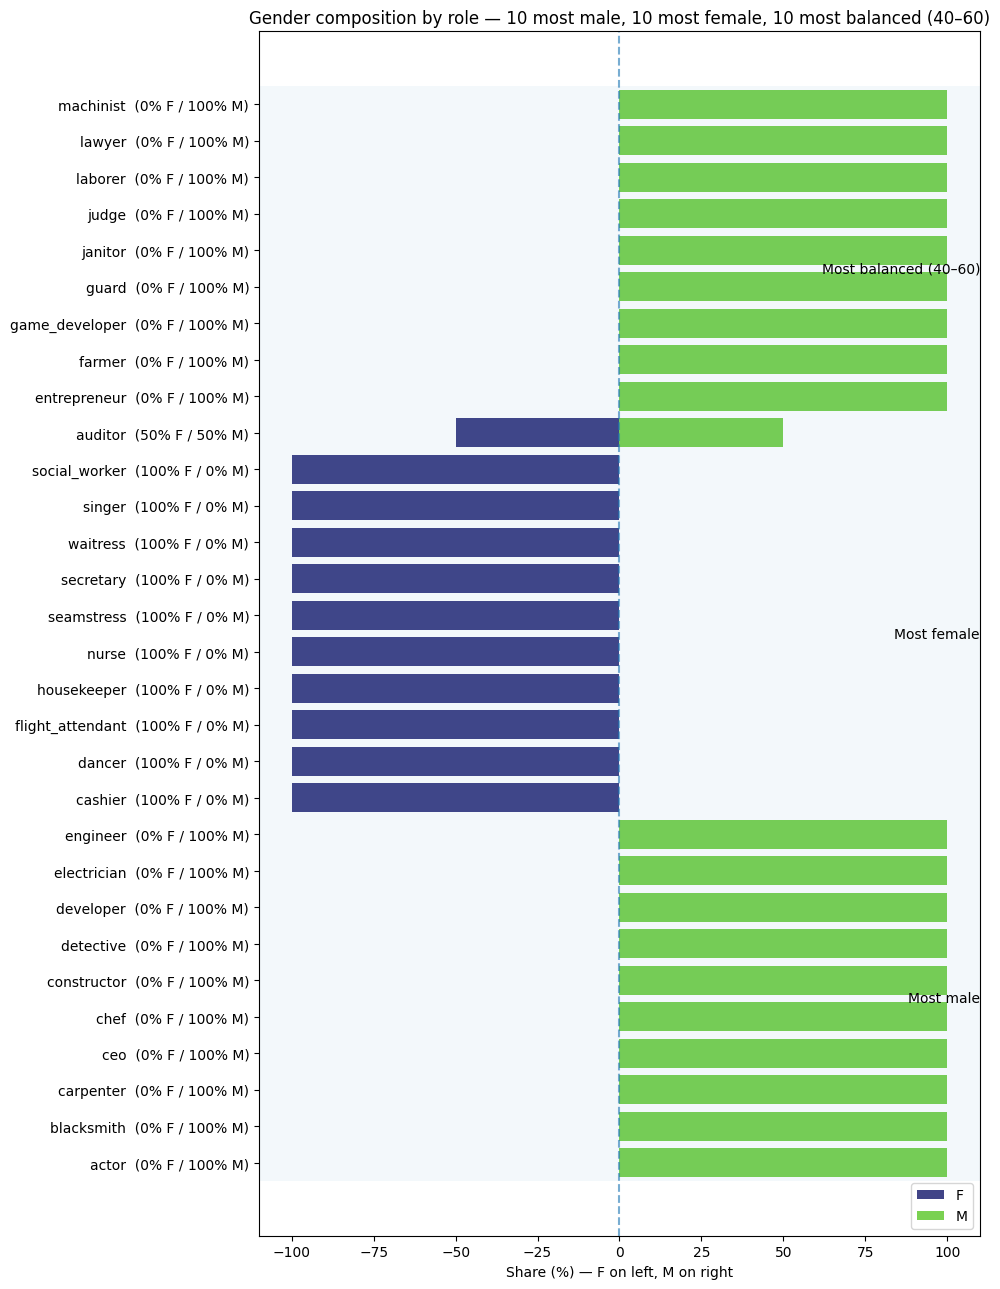

In [19]:
plot_population_pyramid_for_roles(piv, most_male, most_female, most_balanced)

In [22]:
# =============================
# Gender counts for all roles
# =============================
import pandas as pd
import numpy as np

CSV_PATH = "./all_frequencies_role_based.csv"
DIMENSION_NAME = "gender_presentation"
MALE_LABELS = {"male", "man", "masculine"}
FEMALE_LABELS = {"female", "woman", "feminine"}

def get_gender_counts_all_roles(csv_path=CSV_PATH, dimension_name=DIMENSION_NAME):
    # Load
    df = pd.read_csv(csv_path)
    df["sum_context_obs"] = pd.to_numeric(df["sum_context_obs"], errors="coerce").fillna(0).astype(int)

    # Filter to gender dimension and normalize labels
    g = df[df["dimension"].str.lower() == dimension_name.lower()].copy()
    g["label_norm"] = g["label"].str.lower().str.strip()

    # Keep only male/female buckets
    keep = MALE_LABELS.union(FEMALE_LABELS)
    g = g[g["label_norm"].isin(keep)]

    # Pivot to counts per occupation
    piv = g.pivot_table(index="occupation", columns="label_norm",
                        values="sum_context_obs", aggfunc="sum", fill_value=0)

    # Collapse any synonyms into 'male' and 'female'
    male_count   = piv.reindex(columns=list(MALE_LABELS), fill_value=0).sum(axis=1)
    female_count = piv.reindex(columns=list(FEMALE_LABELS), fill_value=0).sum(axis=1)

    out = pd.DataFrame({
        "occupation": piv.index,
        "male_count": male_count.values,
        "female_count": female_count.values
    })

    # Optional: totals and shares (can be handy for sorting/QA)
    out["total"] = out["male_count"] + out["female_count"]
    out["male_share"] = np.where(out["total"]>0, out["male_count"]/out["total"], np.nan)
    out["female_share"] = np.where(out["total"]>0, out["female_count"]/out["total"], np.nan)

    # Sort by total desc (or choose a different sort if you like)
    out = out.sort_values("total", ascending=False).reset_index(drop=True)

    return out[["occupation", "male_count", "female_count", "total", "male_share", "female_share"]]

# ---- Run and save ----
gender_counts = get_gender_counts_all_roles()
print(gender_counts.tail(100).to_string(index=False))  # preview first 20
gender_counts.to_csv("./gender_counts_by_role.csv", index=False)
print("\nSaved: ./gender_counts_by_role.csv")


                     occupation  male_count  female_count  total  male_share  female_share
                          actor          30             0     30         1.0           0.0
                    constructor          30             0     30         1.0           0.0
                      carpenter          30             0     30         1.0           0.0
                        cashier           0            30     30         0.0           1.0
                            ceo          30             0     30         1.0           0.0
                     blacksmith          30             0     30         1.0           0.0
                           chef          30             0     30         1.0           0.0
                        janitor          30             0     30         1.0           0.0
                          judge          30             0     30         1.0           0.0
                        laborer          30             0     30         1.0           0.0